# Progress Report

### Setup

#### Imports

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os




import matplotlib
print(matplotlib.get_backend())
#%matplotlib inline
#import matplotlib
#matplotlib.use("TkAgg")     #for smoother plotting


# From own module import file parser function pandaizer
import parser_timeseries as ts

module://matplotlib_inline.backend_inline


In [2]:
# Patterns
patterns = ["57", "1367", "2049", "2588", "5041", "8732", "14013", "30664", "32232"] #"22053", 
sel_str_values = [0.1, 0.5, 1]

simtime = 250000

# Main results directory
resultsdir = "../../Results/Main_sim_1/"
savedir = "../../Results/Figures/"

#### Readerloop

In [3]:
def readerloop (subdir, patterns, data,
                sel_str_values = [round(0.1 * i, 1) for i in range(1, 11)],
                mut="point",
                mixed=True,
                simtime=250000,
                gridsize="50x50",
                verbose = False):
    
    for pattern in patterns:
        for ss in sel_str_values:
            #if not (pattern == "22053" and ss == 0.1 and mut == "all"):
            data = ts.concatenator(data,
                                   ts.pandaizer(resultsdir + subdir
                                                + mut + "_p"
                                                + pattern + "_t"
                                                + str(int(simtime/1000)) + "k"
                                                + "_s0" + "_ss" + str(ss)
                                                + ("_mixed" if mixed else "") + ".log",
                                                pattern,
                                                mut = mut,
                                                sel_str=ss,
                                                simtime = simtime,
                                                mixed = mixed,
                                                gridsize=gridsize,
                                                verbose=verbose))
    return data

#### Array comparator

In [4]:
def compare_arrays(m_array, u_array, tol=0.01):
    """Returns an array with 0 where the difference is within the tolerance,\n
    1 where m_array is greater, and -1 where u_array is greater."""
    diff = m_array - u_array
    threshold = np.maximum(np.abs(m_array), np.abs(u_array)) * tol
    
    result = np.where(np.abs(diff) <= threshold, 0,
             np.where(diff > 0, 1, -1))
    
    return result

#### Aesthetic functions

In [5]:
def darkener(color, amount=0.7):
    """amount < 1 darkens, amount > 1 lightens"""
    rgb = matplotlib.colors.to_rgb(color)          # accepts name, hex, or tuple
    hsv = matplotlib.colors.rgb_to_hsv(rgb)
    hsv[2] *= amount                      # scale the "value" (brightness) channel
    return matplotlib.colors.hsv_to_rgb(hsv)

### Data reading

#### Low mutations

In [6]:
loadfromcsv = False
csvpath = resultsdir + "df_low.csv"



if loadfromcsv:
    df_low = pd.read_csv(csvpath)



else:
    df_low = ts.empty()

    df_low = readerloop("point_mut/PM_lowmut/", patterns, df_low, sel_str_values=sel_str_values,
                             mut="point", mixed=True)
    df_low = readerloop("point_mut/PN_lowmut/", patterns, df_low, sel_str_values=sel_str_values,
                             mut="point", mixed=False)
    df_low = readerloop("chrom_mut_low/CM_lowmut/", patterns, df_low, sel_str_values=sel_str_values,
                             mut="all", mixed=True)
    df_low = readerloop("chrom_mut_low/CN_lowmut/", patterns, df_low, sel_str_values=sel_str_values,
                             mut="all", mixed=False)
    
    #fix issues with mean distance - where size is zero, set mean distance to 1 (is saved as 0 originally by accident
    df_low["mean_distance"] = df_low.apply(lambda row: np.where(row["size"] == 0, 1, row["mean_distance"]), axis=1)
    
    #store final max fitness values
    df_low["final_max_fitness"] = df_low["maxF"].apply(lambda x: x[-1])
    
    df_low.to_csv(csvpath)



#### High mutations

In [7]:
loadfromcsv = False
csvpath = resultsdir + "df_high.csv"



if loadfromcsv:
    df_high = pd.read_csv(csvpath)



else:
    df_high = ts.empty()

    df_high = readerloop("point_mut_high/PM_high/", patterns, df_high, sel_str_values=sel_str_values,
                             mut="point", mixed=True)
    df_high = readerloop("point_mut_high/PN_high/", patterns, df_high, sel_str_values=sel_str_values,
                             mut="point", mixed=False)
    df_high = readerloop("chrom_mut_high/CM_high/", patterns, df_high, sel_str_values=sel_str_values,
                             mut="all", mixed=True, verbose=False)
    df_high = readerloop("chrom_mut_high/CN_high/", patterns, df_high, sel_str_values=sel_str_values,
                             mut="all", mixed=False, verbose=False)
    
    #fix issues with mean distance - where size is zero, set mean distance to 1 (is saved as 0 originally by accident
    df_high["mean_distance"] = df_high.apply(lambda row: np.where(row["size"] == 0, 1, row["mean_distance"]), axis=1)

    #store final max fitness values
    df_high["final_max_fitness"] = df_high["maxF"].apply(lambda x: x[-1])
    
    df_high.to_csv(csvpath)



### Calculate statistics

In [8]:
def calculate_compared_stat (statname, dslice):

    compared = compare_arrays(m_array=np.mean(np.stack(
                                       dslice[dslice.mixed == "Mixed"][statname]),
                                       axis=0),
                              u_array=np.mean(np.stack(
                                       dslice[dslice.mixed == "Unmixed"][statname]),
                                       axis=0))
    return compared

#### Low mutations

In [9]:
stats_low = {}

size3d = (len(patterns), 2, len(sel_str_values))
size4d = (len(patterns), 2, len(sel_str_values), int(simtime / 10000 + 1))

stats_low["mean_of_mean_distance"] = np.ndarray(size4d)
stats_low["mean_of_least_distance"] = np.ndarray(size4d)
stats_low["labels"] = np.ndarray(size3d, dtype=object)
stats_low["probability_of_success"] = np.ndarray(tuple(list(size3d) + [2]))


for d0, p in enumerate(patterns):
    for d1, mut in enumerate(["point", "all"]):
        for d2, ss in enumerate(sel_str_values):
            
            dslice = df_low[(df_low.target == p) & 
                            (df_low.mutations == mut) & 
                            (df_low.sel_str == ss)
                            ] 
        
            stats_low["mean_of_mean_distance"][d0, d1, d2, :] = calculate_compared_stat("mean_distance", dslice)
            stats_low["mean_of_least_distance"][d0, d1, d2, :] = calculate_compared_stat("least_distance", dslice)
            stats_low["labels"][d0, d1, d2] = str("P" + p + ", S" + str(ss) + ", " + mut + " mutations")
        

            for midx, mix in enumerate(["Mixed", "Unmixed"]):
                values = np.where(dslice[dslice.mixed == mix].final_max_fitness.to_numpy() == 1, 1, 0)
                stats_low["probability_of_success"][d0, d1, d2, midx] = np.sum(values) / values.size




#### High mutations

In [10]:
stats_high = {}

size3d = (len(patterns), 2, len(sel_str_values))
size4d = (len(patterns), 2, len(sel_str_values), int(simtime / 10000 + 1))

stats_high["mean_of_mean_distance"] = np.ndarray(size4d)
stats_high["mean_of_least_distance"] = np.ndarray(size4d)
stats_high["labels"] = np.ndarray(size3d, dtype=object)
stats_high["probability_of_success"] = np.ndarray(tuple(list(size3d) + [2]))

for d0, p in enumerate(patterns):
    for d1, mut in enumerate(["point", "all"]):
        for d2, ss in enumerate(sel_str_values):
            
            dslice = df_high[(df_high.target == p) & 
                            (df_high.mutations == mut) & 
                            (df_high.sel_str == ss)
                            ] 
        
            stats_high["mean_of_mean_distance"][d0, d1, d2, :] = calculate_compared_stat("mean_distance", dslice)
            stats_high["mean_of_least_distance"][d0, d1, d2, :] = calculate_compared_stat("least_distance", dslice)
            stats_high["labels"][d0, d1, d2] = str("P" + p + ", S" + str(ss) + ", " + mut + " mutations")
        

            for midx, mix in enumerate(["Mixed", "Unmixed"]):
                values = np.where(dslice[dslice.mixed == mix].final_max_fitness.to_numpy() == 1, 1, 0)
                stats_high["probability_of_success"][d0, d1, d2, midx] = np.sum(values) / values.size


### Heatmaps

#### Heatmapper

In [11]:
def heatmapper (data, yticks, ax, linefreq = len(patterns)):
    cmap = matplotlib.colors.ListedColormap(["gold", "antiquewhite", "darkmagenta"])
    norm = matplotlib.colors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)
    sns.heatmap(data,
                cbar=False,
                cmap=cmap,
                norm=norm,
                ax=ax,
                yticklabels=yticks)

    cmap = ax.collections[0].cmap
    norm = ax.collections[0].norm
    #!!!!!!!!!!!!!
    #since we're plotting distance with this one, the lower value is closer, so labelling is switched
    #!!!!!!!!!!!!!
    handles = [
        matplotlib.patches.Patch(color=cmap(norm(0)), label="No difference"),
        matplotlib.patches.Patch(color=cmap(norm(-1)),  label="Mixed"), 
        matplotlib.patches.Patch(color=cmap(norm(1)),  label="Unmixed"),
    ]
    for i in range(linefreq, len(yticks), linefreq):
        #ax.hlines(i, xmin=0, xmax=data.shape[1], color='black', linewidth=3)
        ax.axhline(i, color="white", linewidth=2)
    ax.legend(handles=handles, loc="upper right")
    
    #return ax

#### Low mutations

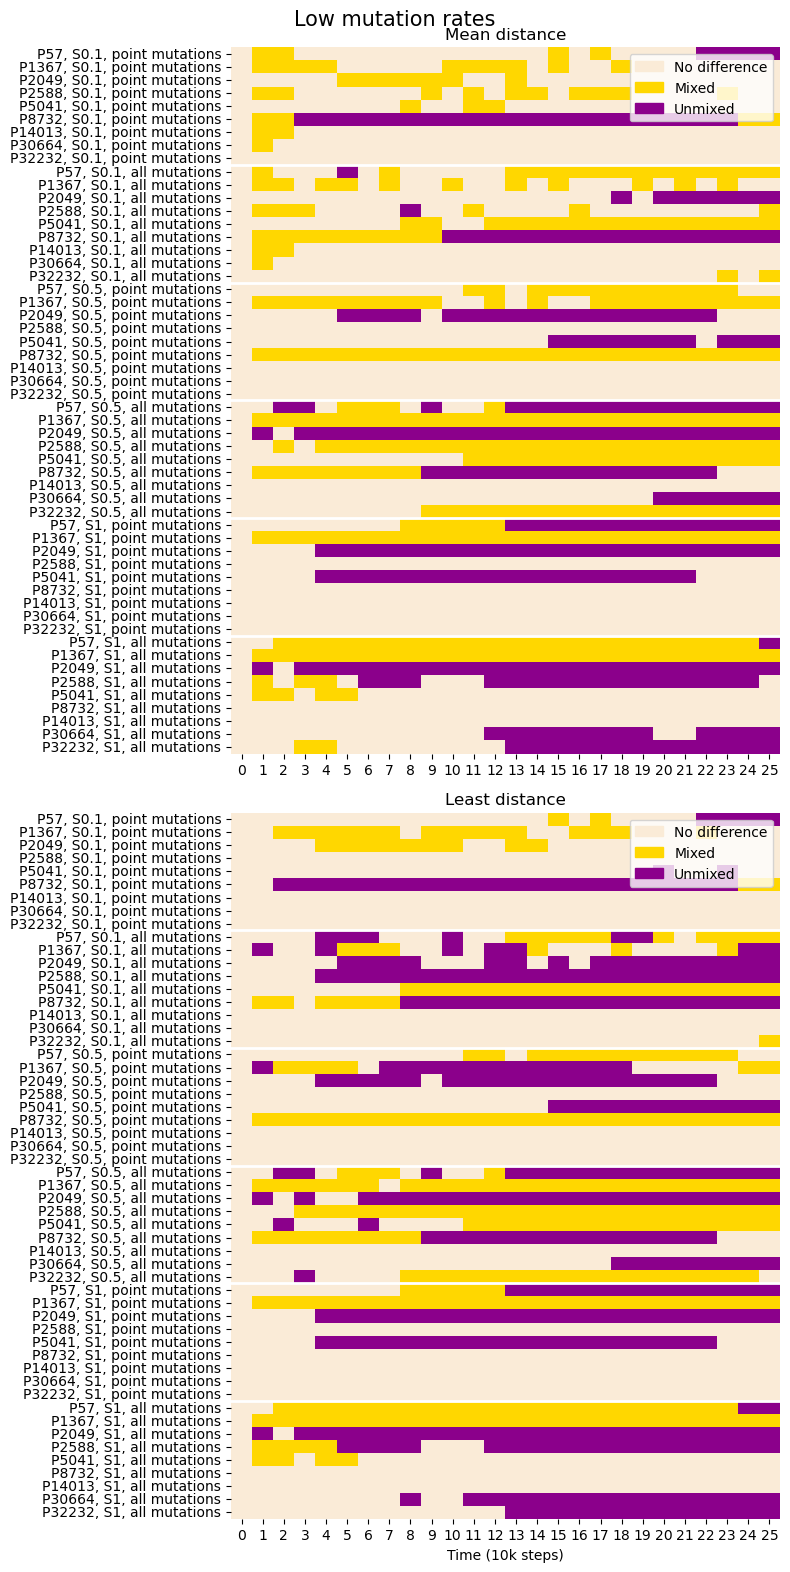

In [12]:
fig, axs = plt.subplots(2, figsize=(8, 16))

#flatten the first two dimensions with .reshape(-1)
heatmapper(stats_low["mean_of_mean_distance"].transpose(2, 1, 0, 3)
                    .reshape(-1, stats_low["mean_of_mean_distance"].shape[3]), 
           yticks = stats_low["labels"].transpose(2, 1, 0).reshape(-1),
           ax=axs[0])
axs[0].set_title("Mean distance")

heatmapper(stats_low["mean_of_least_distance"].transpose(2, 1, 0, 3)
                    .reshape(-1, stats_low["mean_of_least_distance"].shape[3]),
           yticks = stats_low["labels"].transpose(2, 1, 0).reshape(-1),
           ax=axs[1])
axs[1].set_title("Least distance")
axs[1].set_xlabel("Time (10k steps)")

plt.suptitle("Low mutation rates", fontsize=15)
plt.tight_layout()
plt.show()

#### High mutations

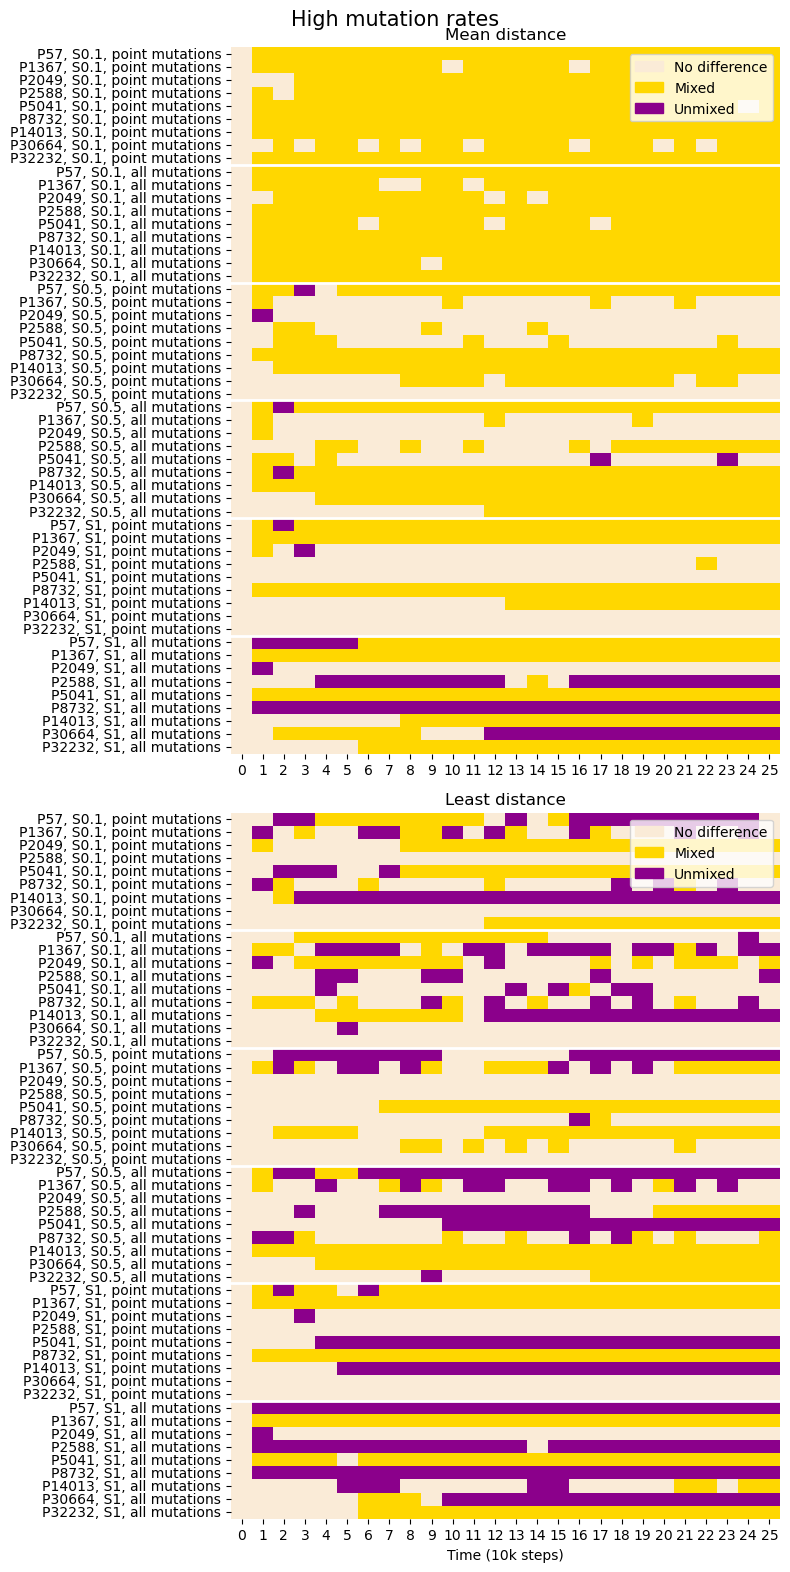

In [13]:
fig, axs = plt.subplots(2, figsize=(8, 16))

#flatten the first two dimensions with .reshape(-1)
heatmapper(stats_high["mean_of_mean_distance"].transpose(2, 1, 0, 3)
                    .reshape(-1, stats_high["mean_of_mean_distance"].shape[3]), 
           yticks = stats_high["labels"].transpose(2, 1, 0).reshape(-1),
           ax=axs[0])
axs[0].set_title("Mean distance")

heatmapper(stats_high["mean_of_least_distance"].transpose(2, 1, 0, 3)
                    .reshape(-1, stats_high["mean_of_least_distance"].shape[3]),
           yticks = stats_high["labels"].transpose(2, 1, 0).reshape(-1),
           ax=axs[1])
axs[1].set_title("Least distance")
axs[1].set_xlabel("Time (10k steps)")

plt.suptitle("High mutation rates", fontsize=15)
plt.tight_layout()
plt.show()

### Explanatory / exploratory plots

#### Mixed-nonmixed comparison visualization

/tmp/ipykernel_2566/3677342131.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["0.1", "", "", "", "", "0.2"])


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

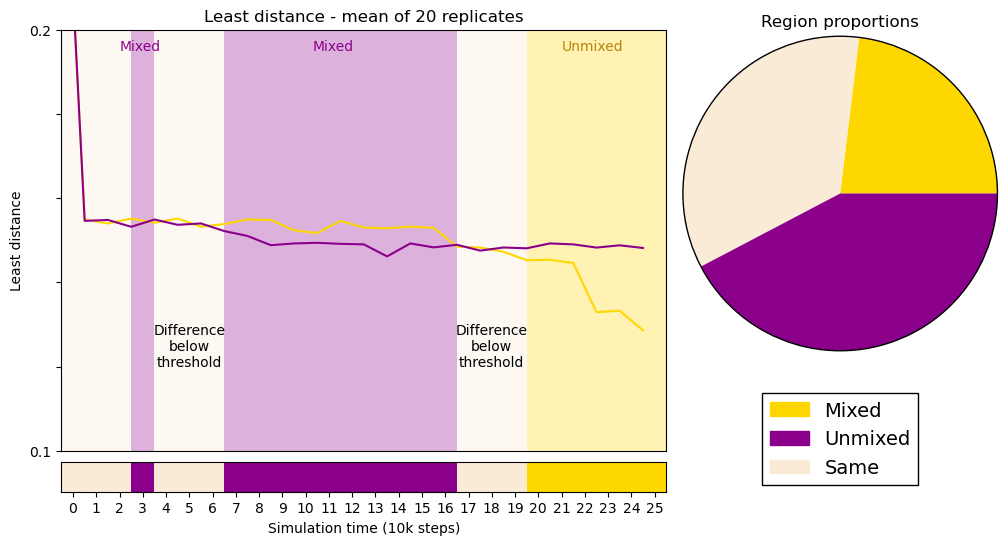

In [42]:
import matplotlib.gridspec as gridspec

xdata = df_high[(df_high.target == "2588") &
               (df_high.sel_str == 0.5) &
               (df_high.mutations == "all")
              ]
mixedmean = np.mean(np.stack(xdata[xdata.mixed == "Mixed"]["least_distance"]), axis=0)
unmixedmean = np.mean(np.stack(xdata[xdata.mixed == "Unmixed"]["least_distance"]), axis=0)
regions = compare_arrays(mixedmean, unmixedmean)


#----------------------------------------------------------------------------------
cmap = matplotlib.colors.ListedColormap(["gold", "antiquewhite", "darkmagenta"])
norm = matplotlib.colors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

# Mapping from raw region value to color, consistent with cmap above.
color_map = {-1: "gold", 0: "antiquewhite", 1: "darkmagenta"}
legend_map = {"Mixed": "gold", "Same": "antiquewhite", "Unmixed": "darkmagenta"}

#----------------------------------------------------------------------------------
fig_height = 6  # inches
strip_cm = 1
strip_in = strip_cm / 2.54
main_in = fig_height - strip_in

fig = plt.figure(figsize=(12, fig_height))
# 3 columns: main plot+strip span cols 0-1, pie chart sits in col 2.
gs = gridspec.GridSpec(2, 2, height_ratios=[main_in, strip_in],
                        width_ratios=[3, 1.5], hspace=0.05, wspace=0.05)

#----------------------------------------------------------------------------------

ax = fig.add_subplot(gs[0, 0])
ax.pcolormesh(regions.reshape(1, -1),
              cmap=cmap, norm=norm,
              alpha=0.3)
ax.plot(range(26), mixedmean, label="Mixed", color="gold")
ax.plot(range(26), unmixedmean, label="Unmixed", color="darkmagenta")
ax.set_ylim(0.1, 0.2)
#ax.legend(loc="lower right")
ax.set_ylabel("Least distance")
ax.text(2.5, 0.195, "Mixed", color="darkmagenta")
ax.text(10.8, 0.195, "Mixed", color="darkmagenta")
ax.text(21.5, 0.195, "Unmixed", color="darkgoldenrod")
ax.text(5.5, 0.12, "Difference\nbelow\nthreshold", color="black", ha="center")
ax.text(18.5, 0.12, "Difference\nbelow\nthreshold", color="black", ha="center")
ax.set_title("Least distance - mean of 20 replicates")
ax.tick_params(bottom=False)
ax.set_xticklabels([])
ax.set_yticklabels(["0.1", "", "", "", "", "0.2"])


#----------------------------------------------------------------------------------

ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(regions.reshape(1, -1),
            cmap=cmap,
            norm=norm,
            ax=ax2,
            cbar=False
           )
ax2.set_yticks([])
ax2.set_xlabel("Simulation time (10k steps)")
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)
ax2.spines['left'].set_visible(True)
ax2.spines['bottom'].set_visible(True)

#----------------------------------------------------------------------------------
# Pie chart spans both rows on the right, vertically centered.
gs_pie = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[:, 1],
                                            height_ratios=[3, 1])
ax3 = fig.add_subplot(gs_pie[0])

#ax3 = fig.add_subplot(gs[:, 1])
values, counts = np.unique(regions, return_counts=True)
colors = [color_map[v] for v in values]
ax3.pie(counts, colors=colors, radius=1.3, startangle=0)
circle = plt.Circle((0, 0), 1.3, fill=False, edgecolor='black', linewidth=1)
circle.set_clip_on(False)
ax3.add_patch(circle)
ax3.set_anchor("S")
#ax3.set_title("Region proportions", fontsize=12)
cell_bbox = gs_pie[0].get_position(fig)  # the pie's grid cell
fig.text(cell_bbox.x0 + cell_bbox.width / 2, cell_bbox.y1,
          "Region proportions", ha="center", va="bottom", fontsize=12
        )

#----------------------------------------------------------------------------------

ax_legend = fig.add_subplot(gs_pie[1])  # the cell you want the legend in
ax_legend.legend(handles=[
                    plt.matplotlib.patches.Patch(color=legend_map["Mixed"], label='Mixed'),
                    plt.matplotlib.patches.Patch(color=legend_map["Unmixed"], label='Unmixed'),
                    plt.matplotlib.patches.Patch(color=legend_map["Same"], label='Same'),
                ], fontsize = 14, loc="center", ncol=1,
                 frameon=True, framealpha=1, edgecolor="black", fancybox=False)
ax_legend.axis("off")  # hide the empty axes' ticks/spines/frame
#plt.tight_layout()

#### Mean and least differences

In [15]:
def mean_and_least_calculator (df, sortorder):
    df["diff_mean_and_least_distance"] = df.apply(lambda row: np.abs(row["least_distance"] - row["mean_distance"]), axis=1)

    grouped = (df#[df.mixed == "Unmixed"]
              .sort_values(sortorder)
              .groupby(sortorder, sort=False)
              ["diff_mean_and_least_distance"]
              .apply(lambda x: np.mean(np.stack(x), axis=0)))

    return grouped

def mean_and_least_plotter (df, sortorder,
                            minor_lines = False,
                            major_lines = False,
                            suptitle=""):

    grouped = mean_and_least_calculator(df, sortorder)
    labels = [', '.join(map(str, idx)) for idx in grouped.index]

    fig, ax = plt.subplots(figsize=(15, 25))
    sns.heatmap(np.array(grouped.tolist()),
                yticklabels=labels, ax=ax)
    
    if minor_lines:
        for i in range(minor_lines, len(labels), minor_lines):
            ax.axhline(i, color="white", linewidth=0.5)

    if major_lines:
        for i in range(major_lines, len(labels), major_lines):
            ax.axhline(i, color="white", linewidth=3)
    
    fig.subplots_adjust(wspace=0.35, hspace=0.1, left=0.07, right=0.9, top=0.96, bottom=0.15)
    
    fig.canvas.draw()  # forces layout so get_position() is accurate
    bbox = ax.get_position()
    center_x = (bbox.x0 + bbox.x1) / 2

    fig.suptitle(suptitle,
                 x=center_x, fontsize=24, ha="center")
    return fig, ax



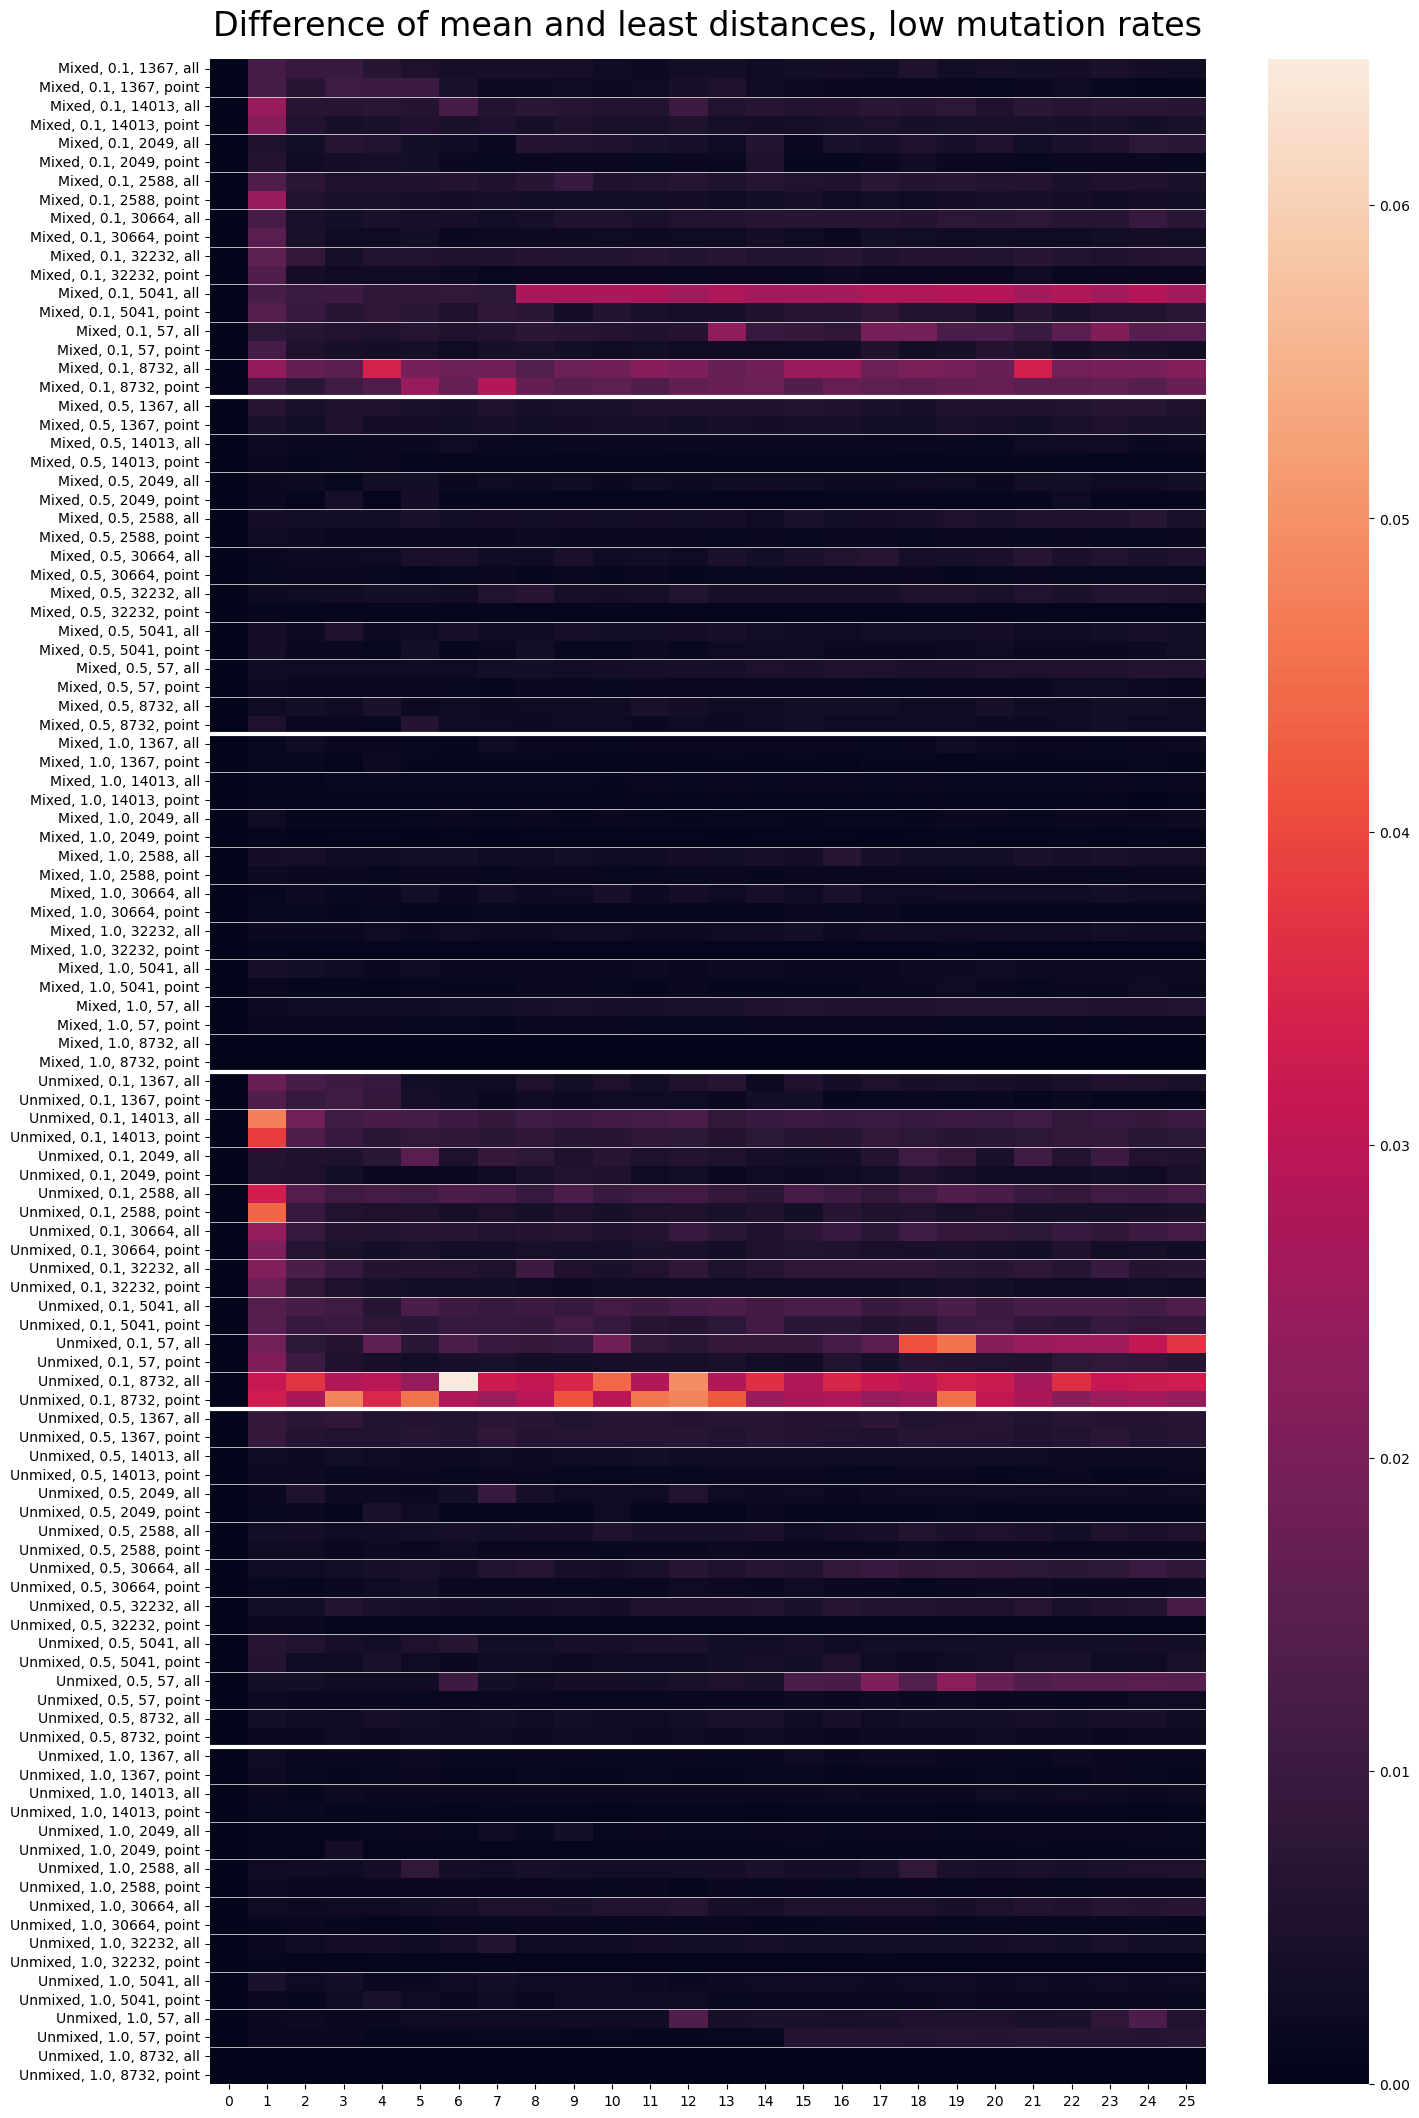

In [16]:
fig, ax = mean_and_least_plotter(df_low, ["mixed", "sel_str", "target", "mutations"],
                                 minor_lines=2,
                                 major_lines=len(patterns) * 2,
                                 suptitle="Difference of mean and least distances, low mutation rates"
                                )

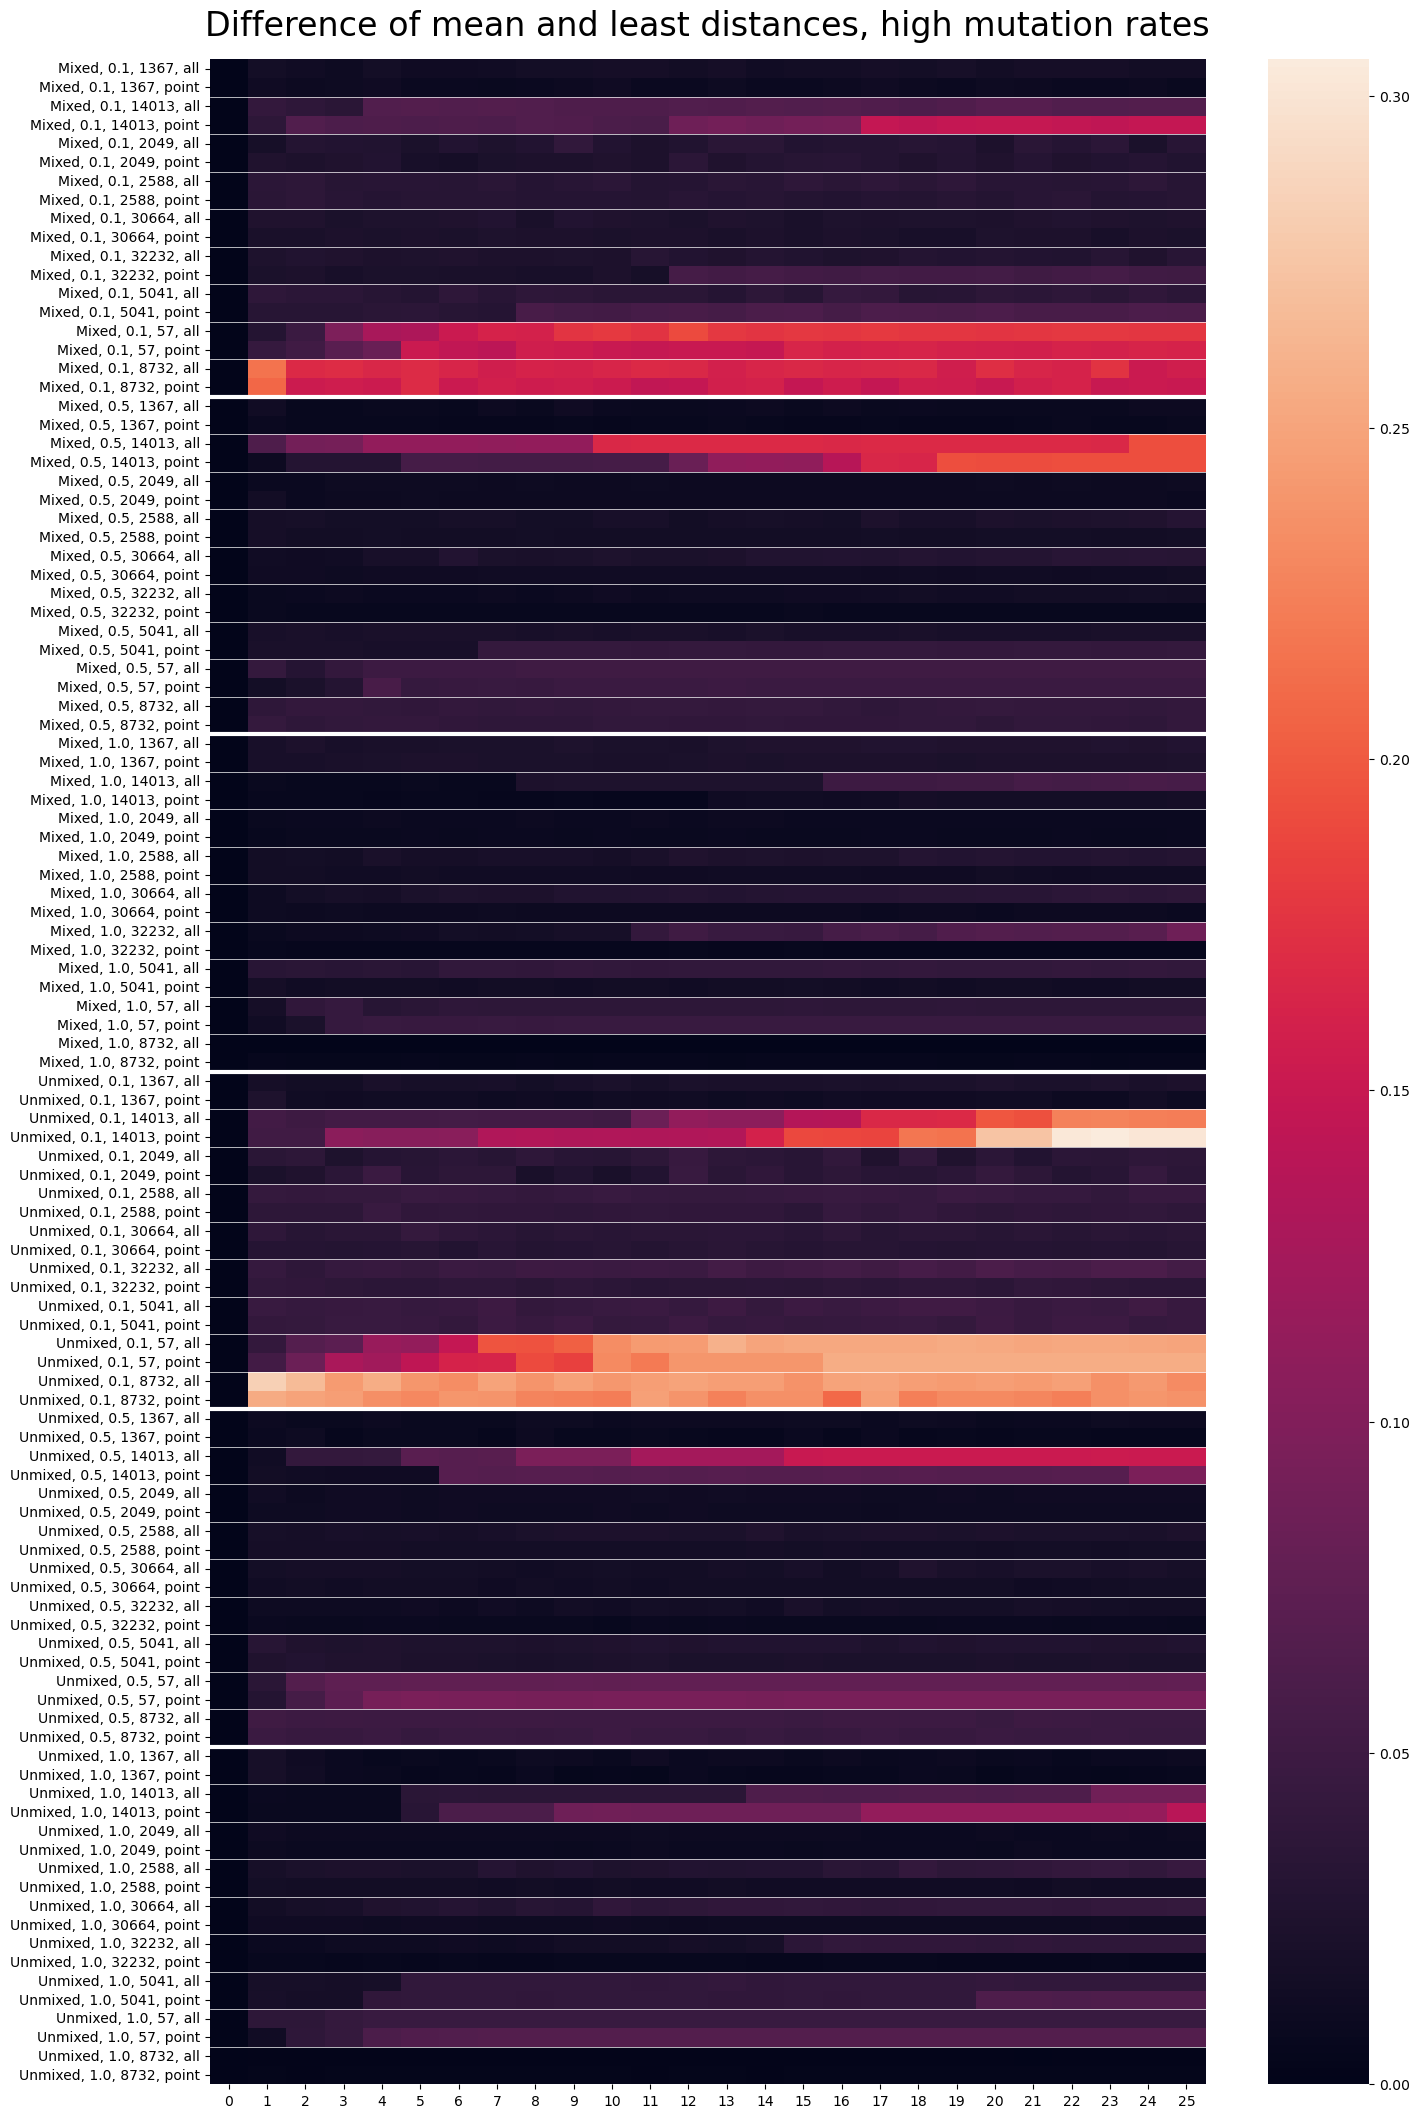

In [17]:
fig, ax = mean_and_least_plotter(df_high, ["mixed", "sel_str", "target", "mutations"],
                                 minor_lines=2,
                                 major_lines=len(patterns) * 2,
                                 suptitle="Difference of mean and least distances, high mutation rates"
                                )

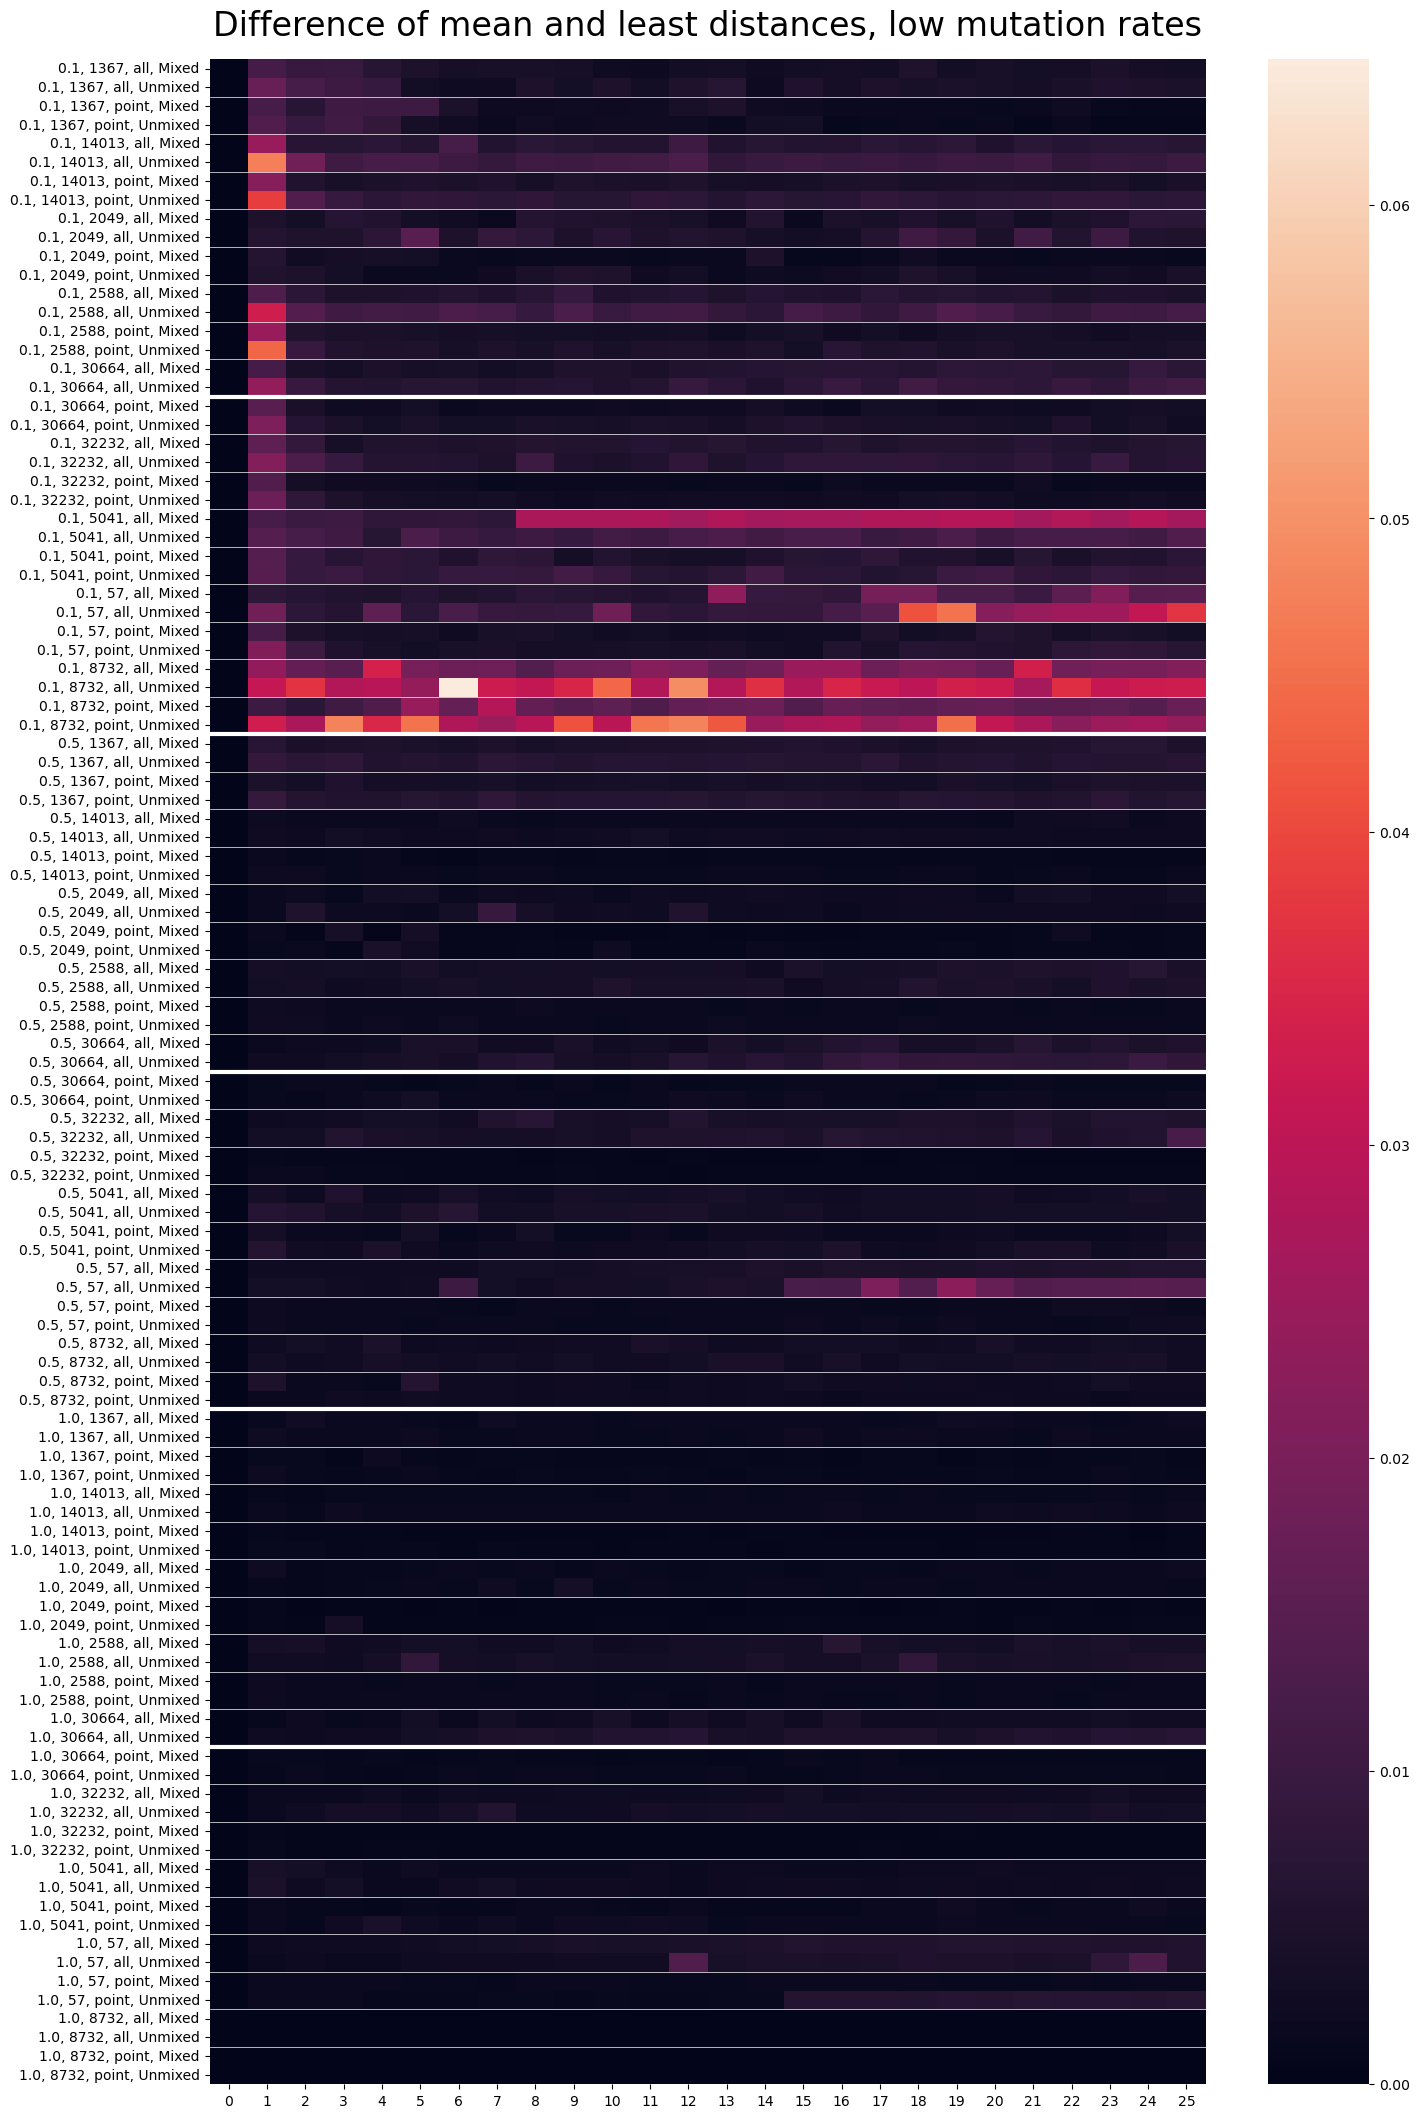

In [18]:
fig, ax = mean_and_least_plotter(df_low, ["sel_str", "target", "mutations", "mixed"],
                                 minor_lines=2,
                                 major_lines=len(patterns) * 2,
                                 suptitle="Difference of mean and least distances, low mutation rates"
                                )

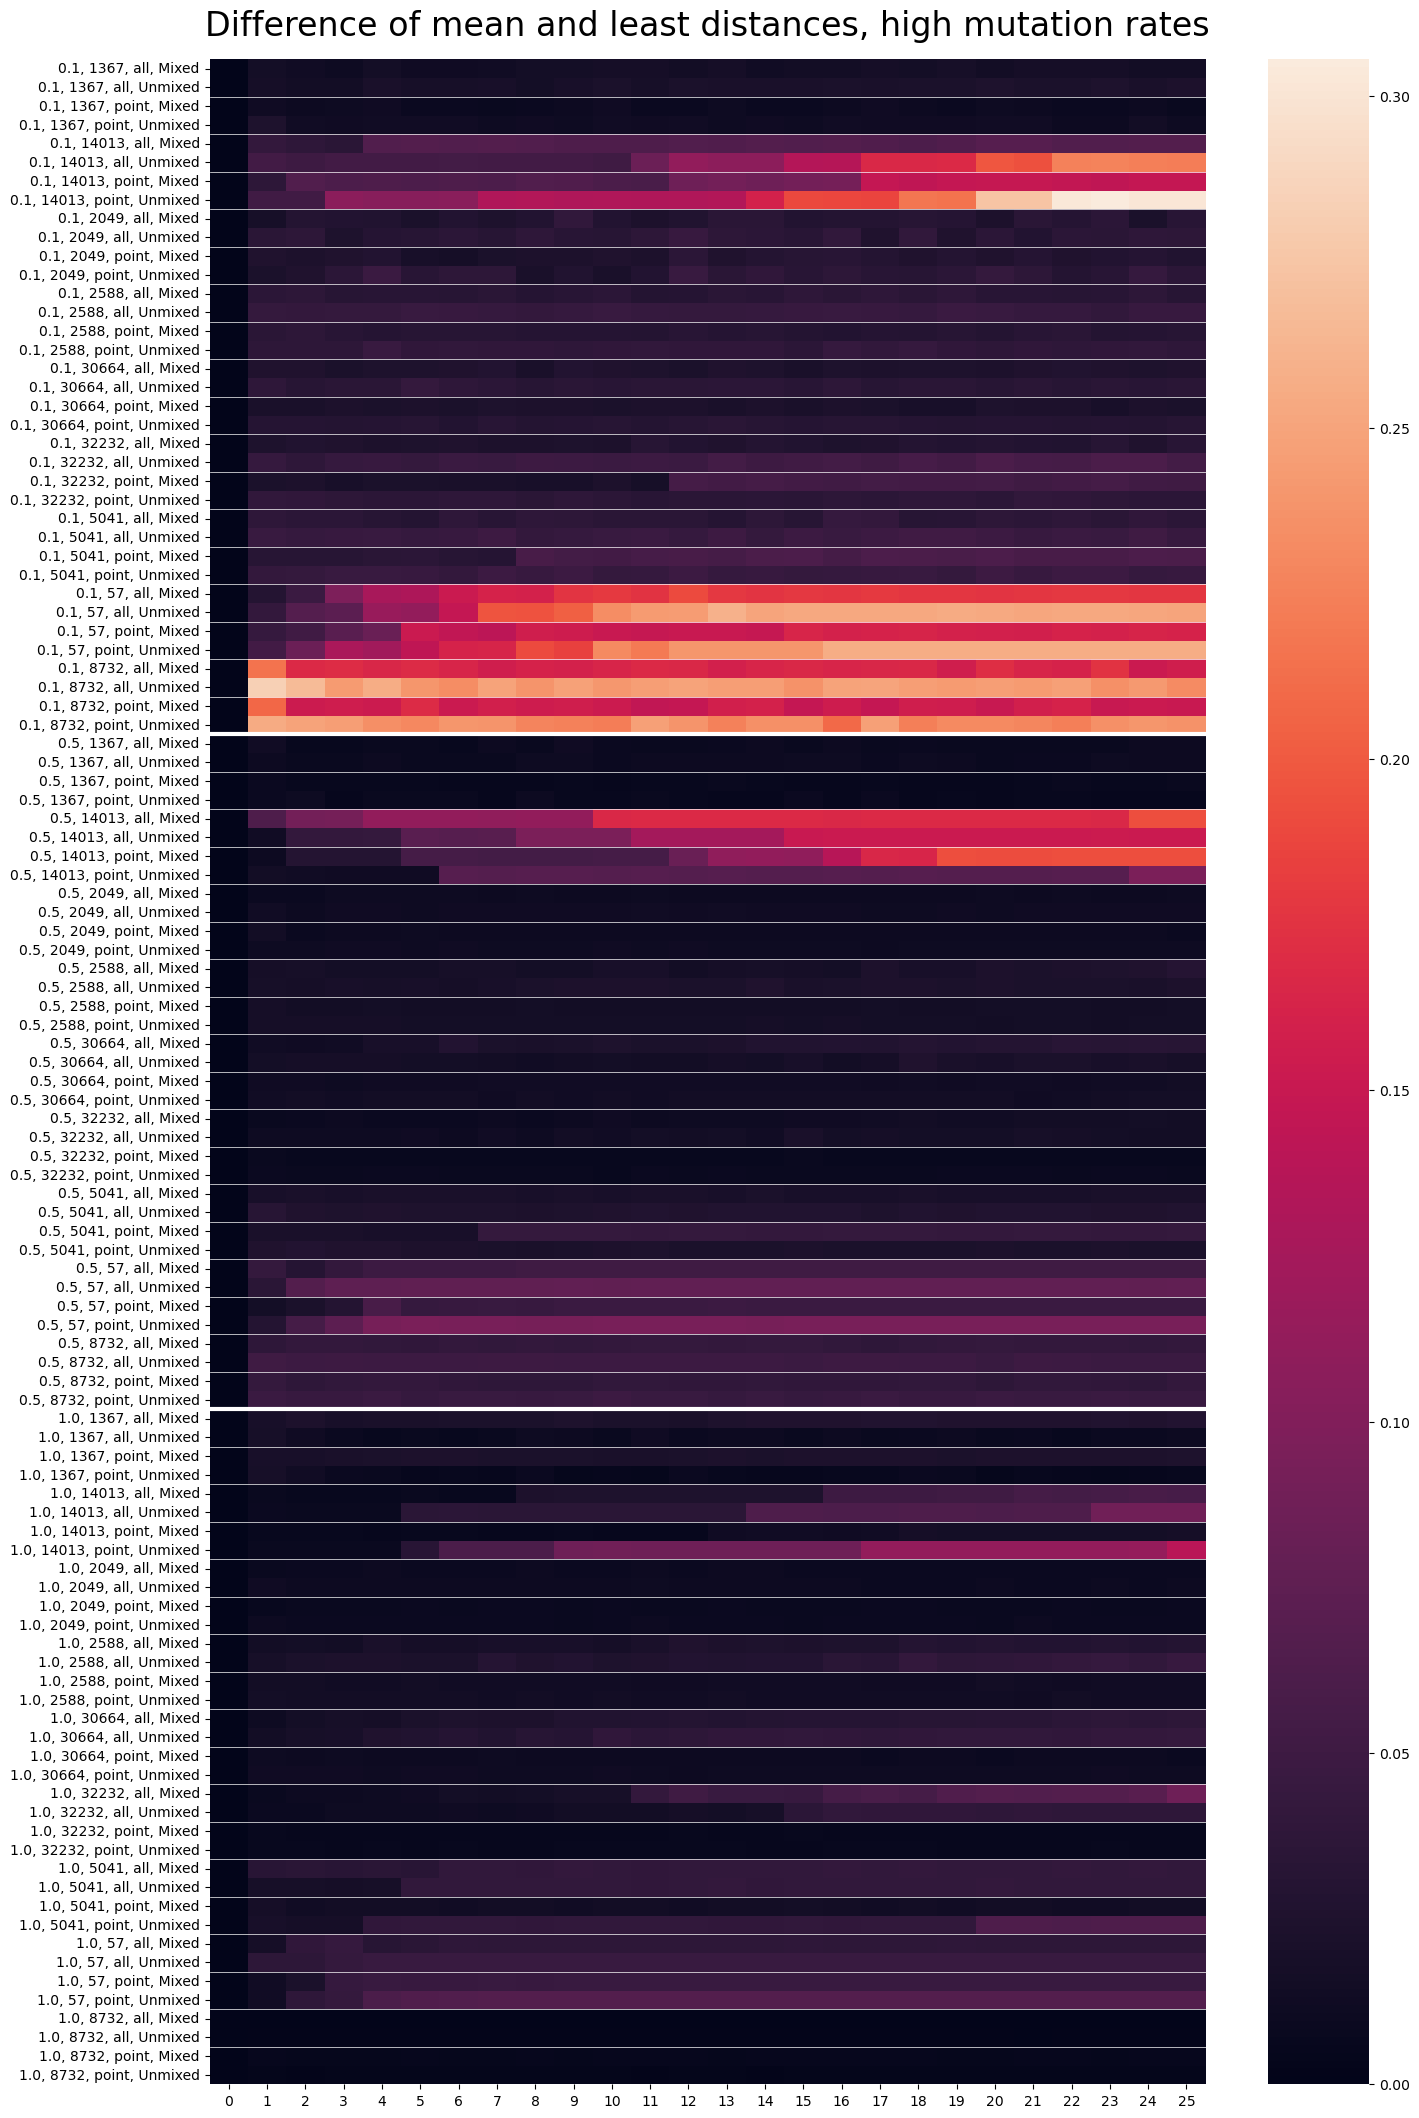

In [19]:
fig, ax = mean_and_least_plotter(df_high, ["sel_str", "target", "mutations", "mixed"],
                                 minor_lines=2,
                                 major_lines=len(patterns) * 2 *2,
                                 suptitle="Difference of mean and least distances, high mutation rates"
                                )

### Piecharts

#### Piecharter

In [27]:
def piecharter (statsmatrix):
    
    # no. of patterns,
        #mut modes,
        #selection strength,
        #measurements
    statsmatrix = statsmatrix.reshape(-1, statsmatrix.shape[2], statsmatrix.shape[3]).transpose(1,0,2)
    shape = statsmatrix.shape
    fig, axs = plt.subplots(len(sel_str_values), len(patterns) * 2, figsize=(24, 4.5))

    label_map = {-1: "Mixed", 0: "Same", 1: "Unmixed"} #because we are dealing with distance
    color_map = {"Mixed": "gold", "Same": "antiquewhite", "Unmixed": "darkmagenta"}
    for row, ss in enumerate(sel_str_values):
        for pidx, pattern in enumerate(patterns):
            for midx, mut in enumerate(["point", "all"]):
                col = pidx * 2 + midx            
             
                values, counts = np.unique(statsmatrix[row, col, :], return_counts=True)
                #labels = [label_map[v] for v in values]
                colors = [color_map[label_map[v]] for v in values]
                
                axs[row][col].pie(counts, colors=colors, radius=1.5,
                                  startangle=0)#, labels=labels)
                if row == 2:
                    axs[row][col].set_xlabel(pattern + ", " + mut, labelpad=20,
                                             fontsize=24, rotation = -60, ha="left")
                    axs[row][col].xaxis.label.set_position((0,0))
                else:
                    axs[row][col].set_xlabel("")

                if col == 0:
                    axs[row][col].set_ylabel(ss, labelpad=20,
                                             fontsize=24, rotation = 90)
                    #axs[row][col].xaxis.label.set_position((0,0))
                else:
                    axs[row][col].set_ylabel("")
                    
                circle = plt.Circle((0, 0), 1.5, fill=False, edgecolor='black', linewidth=1.5)
                circle.set_clip_on(False)
                axs[row][col].add_patch(circle)
                #axs[row][col].set_xlim(-1.5, 1.5)
                #axs[row][col].set_ylim(-1.5, 1.5)
    
    fig.legend(handles=[
                    plt.matplotlib.patches.Patch(color=color_map["Mixed"], label='Mixed'),
                    plt.matplotlib.patches.Patch(color=color_map["Unmixed"], label='Unmixed'),
                    plt.matplotlib.patches.Patch(color=color_map["Same"], label='Same'),
                ], loc='outside right center', fontsize = 18)                

    fig.text(0.02, 0.5,
         'Selection parameter',
         ha='left', va='center', rotation='vertical', fontsize=24)
    
    #plt.tight_layout()
    plt.subplots_adjust(wspace=0.35, hspace=0.1, left=0.07, right=0.9, top=0.85, bottom=0.15)
    #plt.subplots_adjust(right=0.9)
    
    for j in range(2, len(patterns) * 2, 2):
    # get position of axes[0, j] in figure coordinates
        x_left  = axs[0, j-1].get_position().x1  # right edge of left column
        x_right = axs[0, j].get_position().x0    # left edge of right column
        x_mid   = (x_left + x_right) / 2
        line = plt.Line2D([x_mid, x_mid], [0.15, 0.85], transform=fig.transFigure,
                      color='black', linewidth=3)
        fig.add_artist(line)

    
    
    
    
    return fig, axs
    

#### Low mutations

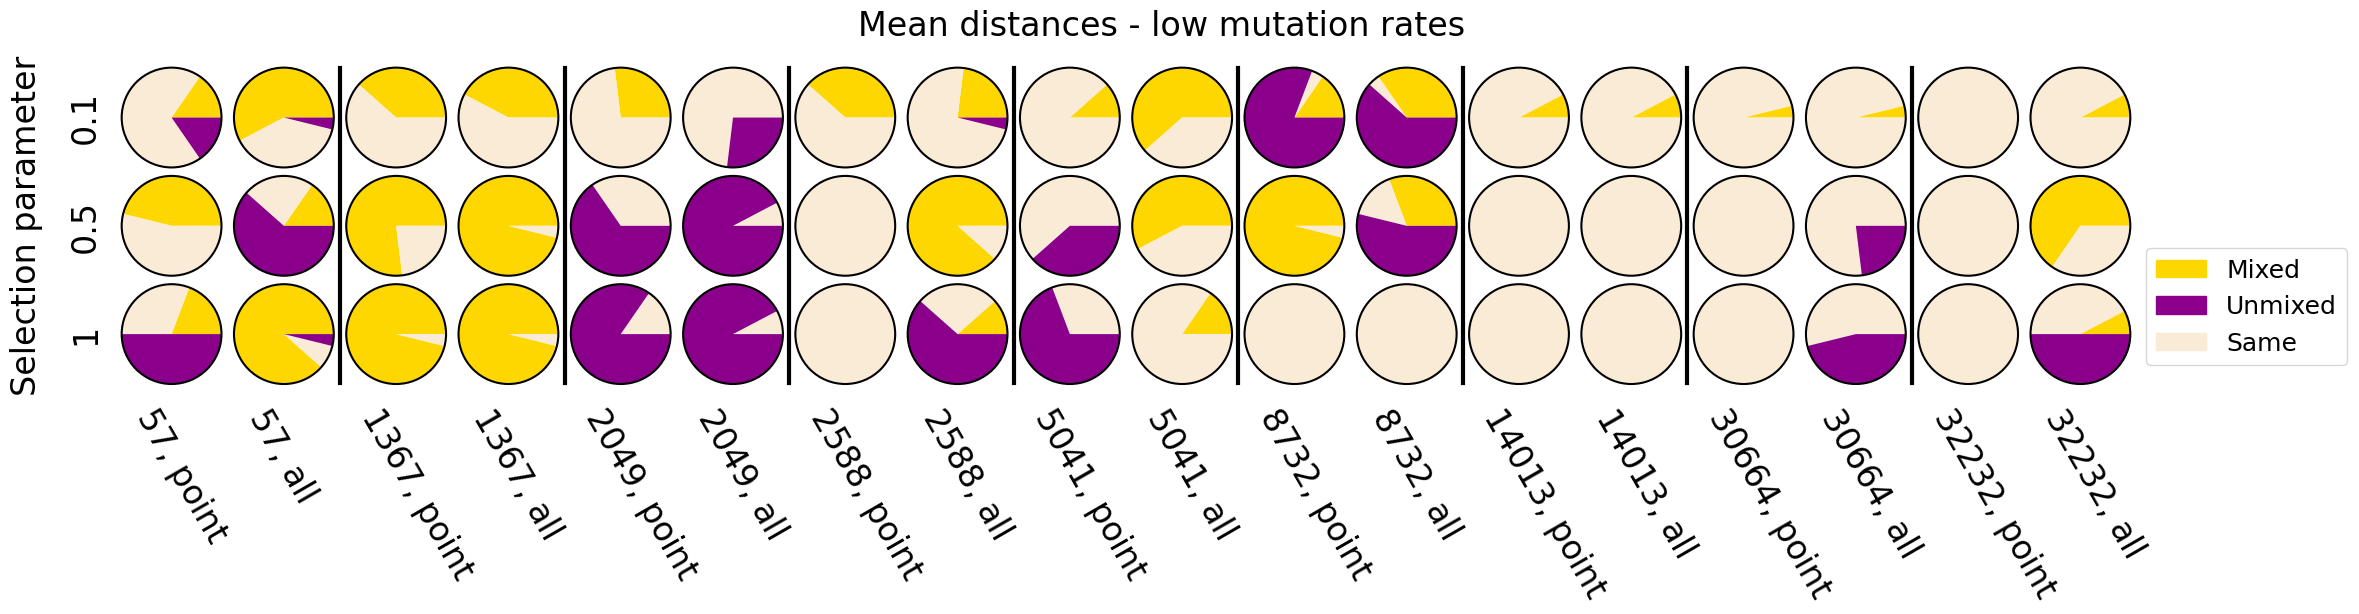

In [28]:
fig, axs = piecharter (stats_low["mean_of_mean_distance"])
fig.suptitle("Mean distances - low mutation rates", fontsize=24)
plt.show()

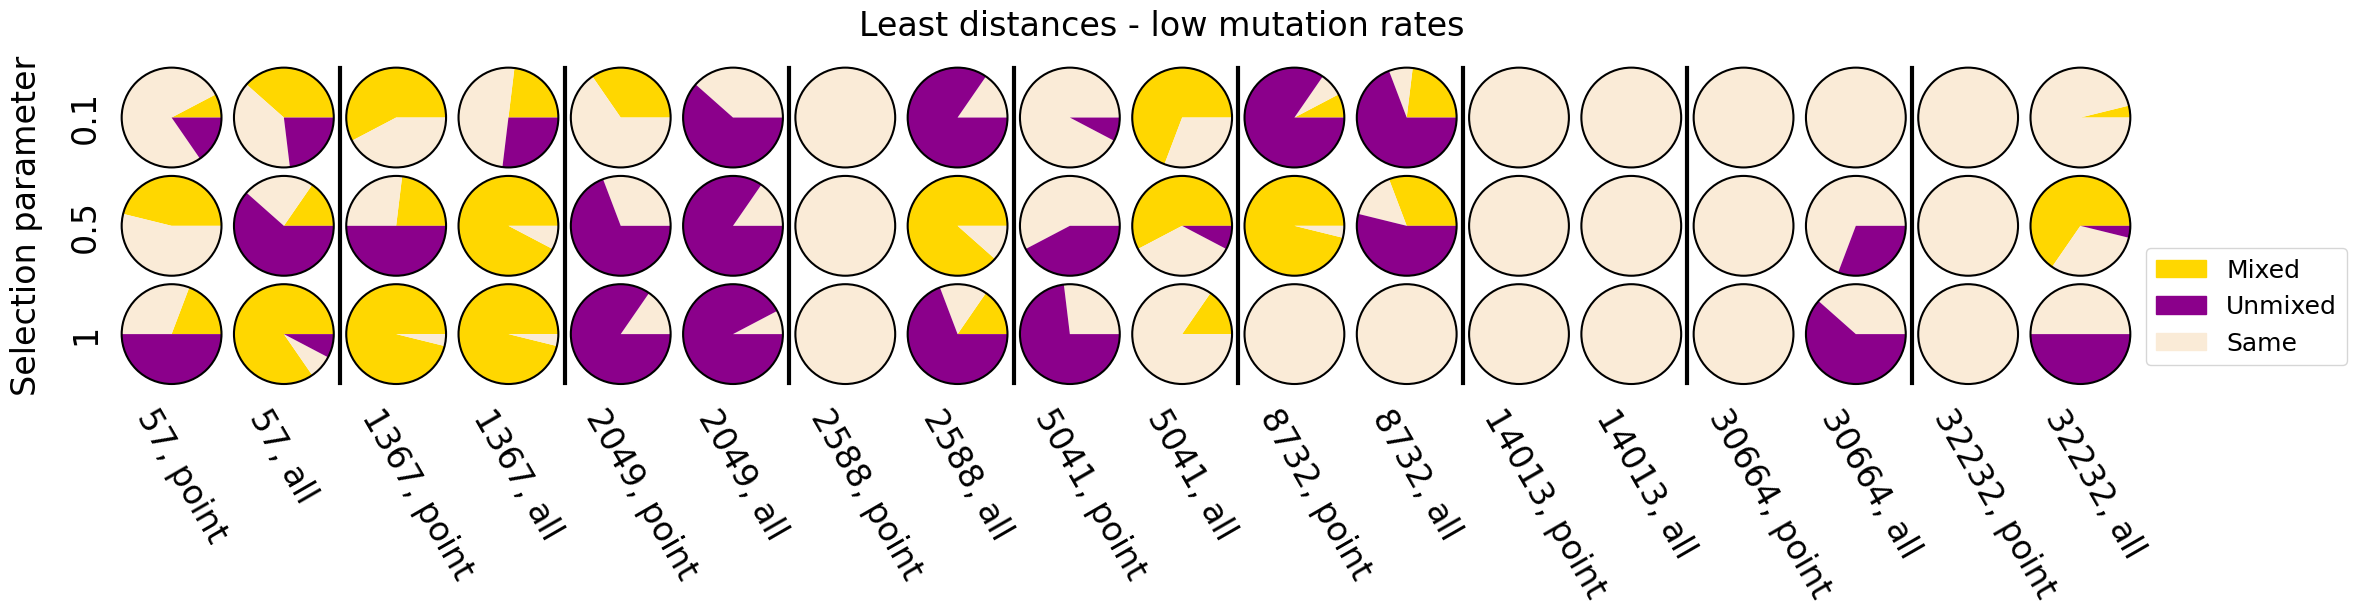

In [29]:
fig, axs = piecharter (stats_low["mean_of_least_distance"])
fig.suptitle("Least distances - low mutation rates", fontsize=24)
plt.show()

#### High mutations

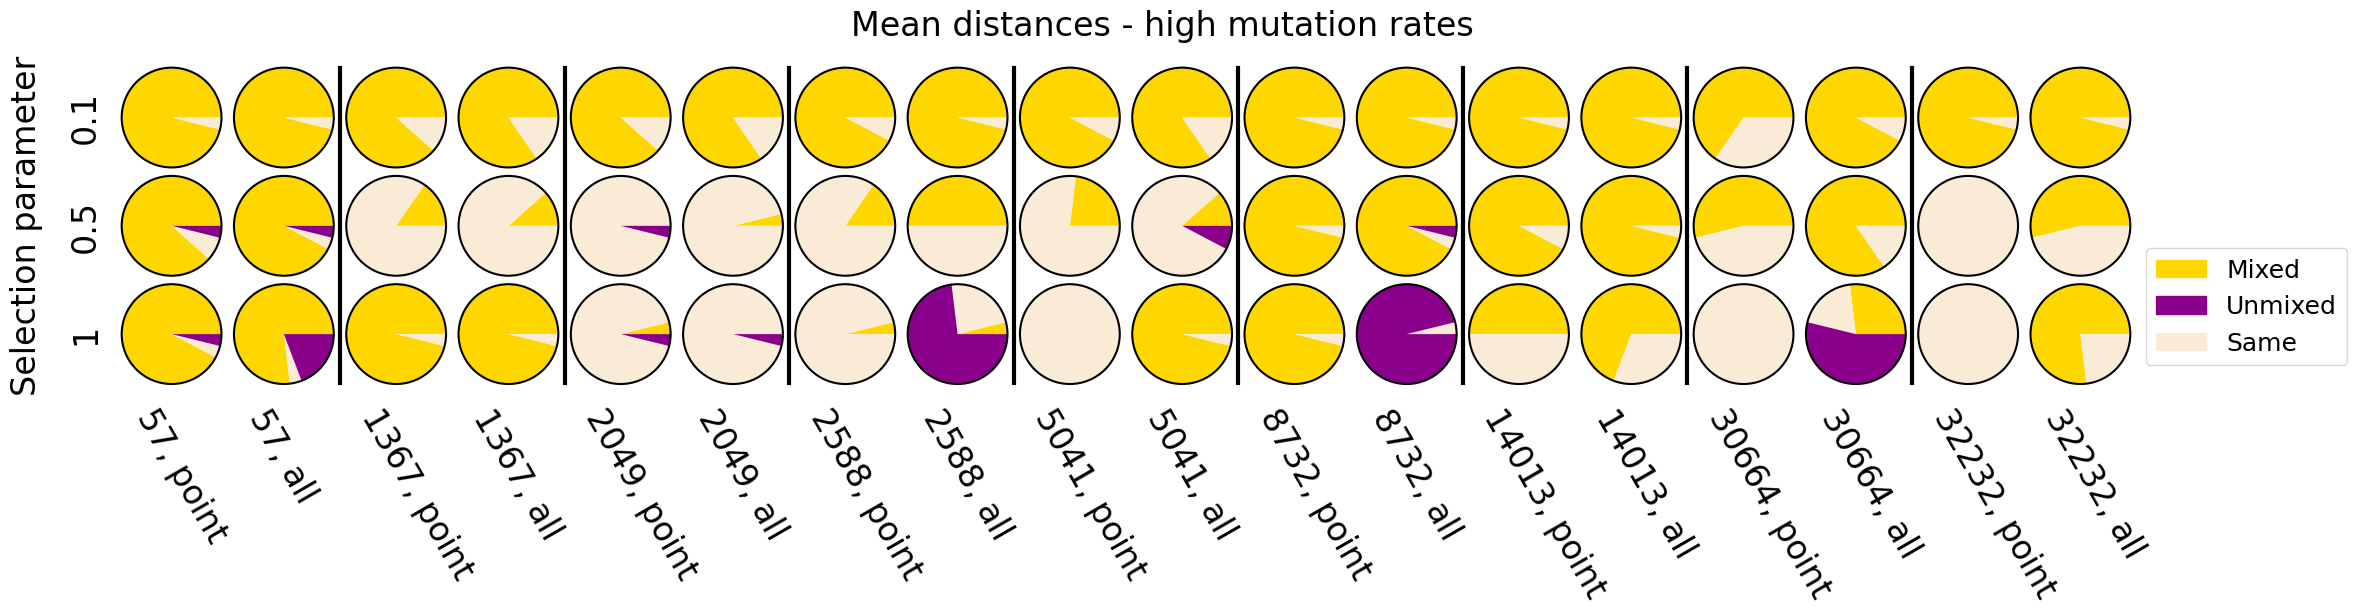

In [30]:
fig, axs = piecharter (stats_high["mean_of_mean_distance"])
fig.suptitle("Mean distances - high mutation rates", fontsize=24)
plt.show()

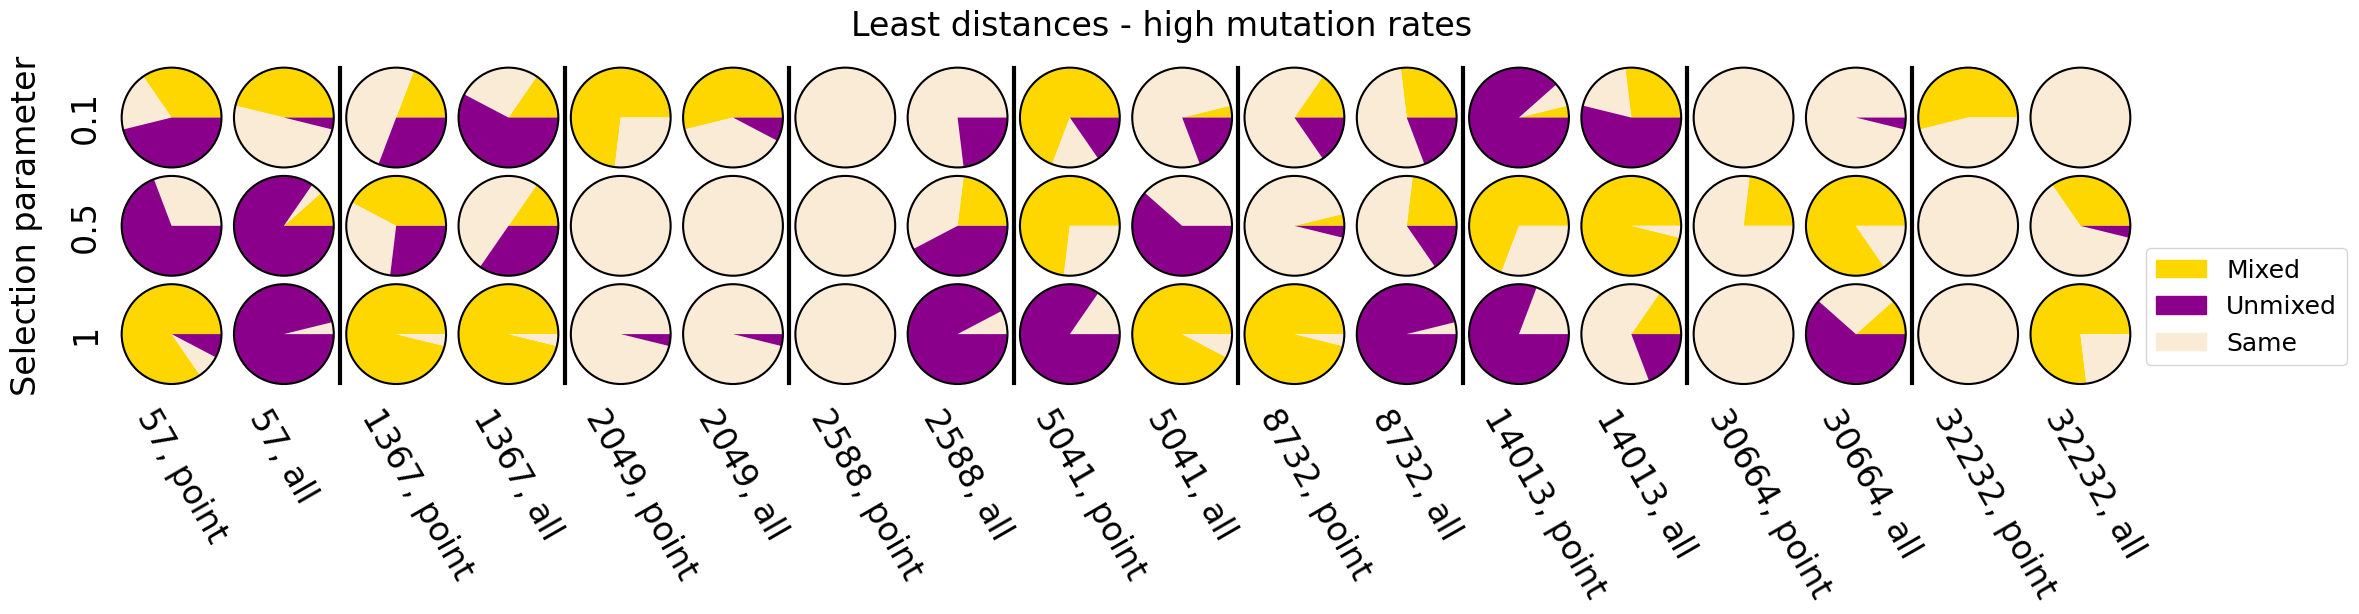

In [31]:
fig, axs = piecharter (stats_high["mean_of_least_distance"])
fig.suptitle("Least distances - high mutation rates", fontsize=24)
plt.show()

### Condition comparison barplots

#### Plot means only

0 0.1
1 0.5
2 1


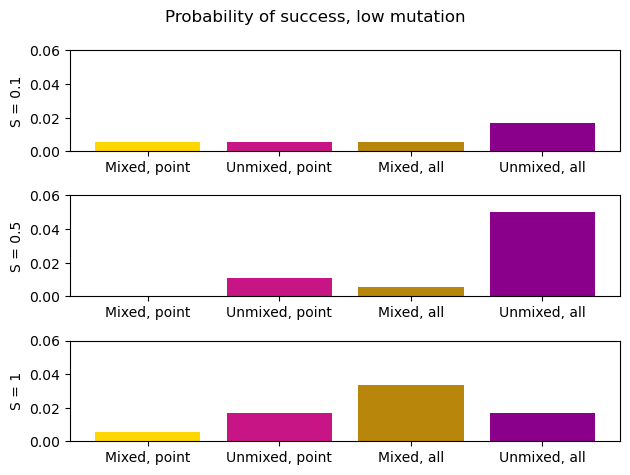

In [32]:
fig, axs = plt.subplots(3)

for ax, (d2, ss) in zip(axs, enumerate(sel_str_values)): 
    print(d2, ss)
    values = []
    labels = []
    for d1, mut in enumerate(["point", "all"]):
        for d3, mix in enumerate(["Mixed", "Unmixed"]):
            values.append(np.mean(stats_low["probability_of_success"][:, d1, d2, d3]))#.sum(0) / stats_low["probability_of_success"].shape[0])
            labels.append(mix + ", " + mut)
    ax.bar(labels, values, color = ["gold", "mediumvioletred", "darkgoldenrod", "darkmagenta"])
    ax.set_ylim(0, 0.06)
    ax.set_ylabel("S = " + str(ss))

plt.suptitle("Probability of success, low mutation")

plt.tight_layout()

0 0.1
1 0.5
2 1


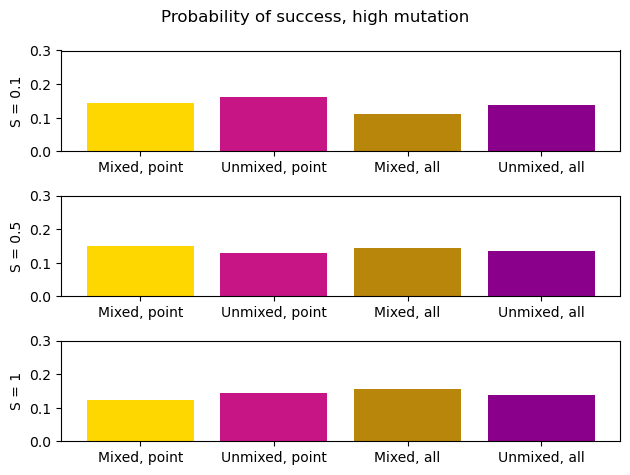

In [33]:
fig, axs = plt.subplots(3)

for ax, (d2, ss) in zip(axs, enumerate(sel_str_values)): 
    print(d2, ss)
    values = []
    labels = []
    for d1, mut in enumerate(["point", "all"]):
        for d3, mix in enumerate(["Mixed", "Unmixed"]):
            values.append(np.mean(stats_high["probability_of_success"][:, d1, d2, d3]))
            labels.append(mix + ", " + mut)
    ax.bar(labels, values, color = ["gold", "mediumvioletred", "darkgoldenrod", "darkmagenta"])
    ax.set_ylim(0, 0.3)
    ax.set_ylabel("S = " + str(ss))

plt.suptitle("Probability of success, high mutation")

plt.tight_layout()

#### Plot means with bar + scatter

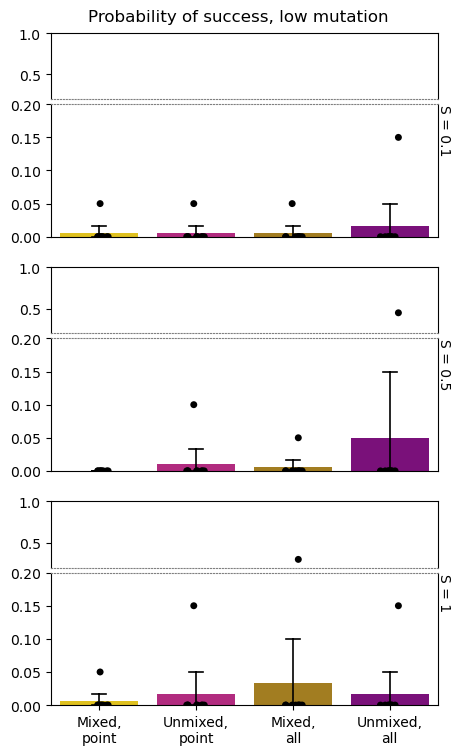

In [34]:
def conditions_barplotter_full (statsmatrix, suptitle="", separation=0.1):
    
    fig = plt.figure(figsize=(5, 8))
    # 3 columns: main plot+strip span cols 0-1, pie chart sits in col 2.
    gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1], hspace=0.15, top=0.95)
    
    for d2, ss in enumerate(sel_str_values):
        sub_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[d2],
                                                  height_ratios=[1, 2],
                                                  hspace=0.05)
        ax_top = fig.add_subplot(sub_gs[0,0])
        ax_bottom = fig.add_subplot(sub_gs[1,0])
    
        values = []
        labels = []
        for d1, mut in enumerate(["point", "all"]):
            for d3, mix in enumerate(["Mixed", "Unmixed"]):
                values.append(statsmatrix[:, d1, d2, d3])
                labels.append(mix + ",\n" + mut)
        
        data=pd.DataFrame(dict(zip(labels, values)))
    
        for ax in [ax_top, ax_bottom]:
            
            sns.barplot(data=data, ax=ax,
                        errorbar="ci",
                        err_kws={"linewidth": 1.2, "color": "black"},
                        capsize=0.15,
                        palette=["gold", "mediumvioletred", "darkgoldenrod", "darkmagenta"]
                        )
            np.random.seed(0)
            sns.stripplot(data=data,
                          ax=ax,
                          palette=["black" for i in range(4)]
                         )
            ax.set_xlabel("")
            ax.tick_params(bottom=False)
            ax.set_xticklabels([])
            
        ax_top.spines['bottom'].set_linestyle(":")
        ax_top.spines["bottom"].set_color("gray")
        ax_top.set_ylim(separation, 1)
        ax_bottom.spines['top'].set_linestyle(":")
        ax_bottom.spines['top'].set_color("gray")
        ax_bottom.set_ylim(0, separation)
        
        ax_bottom.yaxis.set_label_position("right")
        ax_bottom.set_ylabel("S = " + str(ss), rotation=-90, va="center", ha="left")
        ax_bottom.yaxis.label.set_position((0,1))

    fig.axes[-1].tick_params(bottom=True)
    fig.axes[-1].set_xticks(range(4))
    fig.axes[-1].set_xticklabels(labels)

    fig.suptitle(suptitle)
    #fig.tight_layout()
    return fig


fig_low = conditions_barplotter_full(stats_low["probability_of_success"],
                                     suptitle="Probability of success, low mutation",
                                     separation=0.2
                                  )

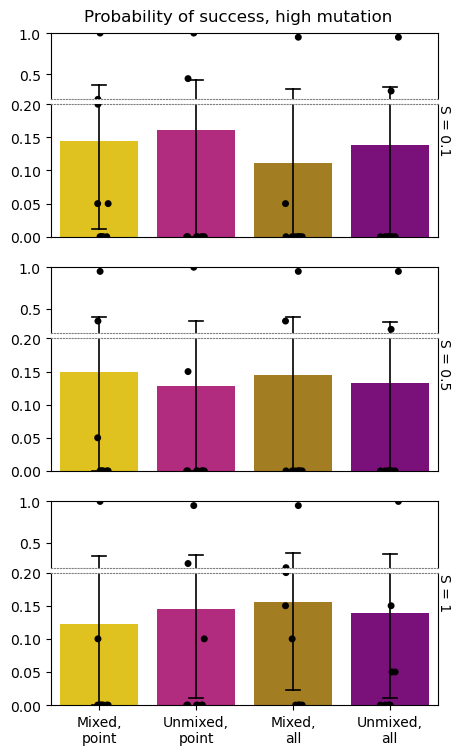

In [35]:
fig_high = conditions_barplotter_full(stats_high["probability_of_success"],
                                      suptitle="Probability of success, high mutation",
                                      separation=0.2
                                     )

#### Plot means with scatters

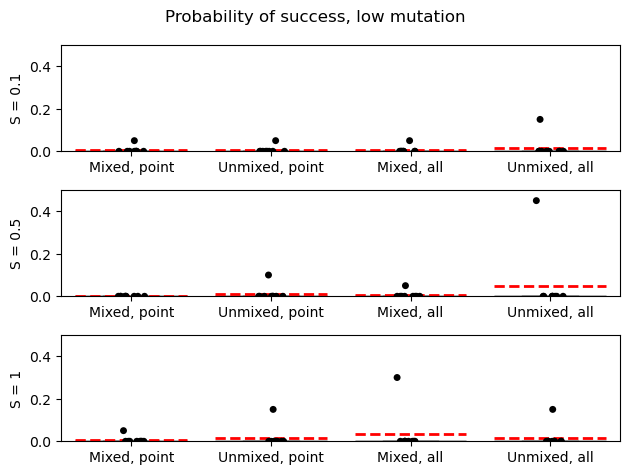

In [36]:
def conditions_boxplotter (statsmatrix, suptitle="", ylim = (0, 0.3)):
    
    fig, axs = plt.subplots(len(sel_str_values), 1)
    
    for ax, (d2, ss) in zip(axs, enumerate(sel_str_values)):
        values = []
        labels = []
        for d1, mut in enumerate(["point", "all"]):
            for d3, mix in enumerate(["Mixed", "Unmixed"]):
                values.append(statsmatrix[:, d1, d2, d3])
                labels.append(mix + ", " + mut)
        sns.boxplot(data=pd.DataFrame(dict(zip(labels, values))),
                    ax=ax,
                    fliersize=0,
                    showmeans=True,
                    meanline=True,
                    meanprops={'color': 'red', 'linewidth': 2}
                   )
        sns.stripplot(data=pd.DataFrame(dict(zip(labels, values))),
                      ax=ax,
                      palette=["black" for i in range(4)]
                     )
        ax.set_ylim(ylim)
        ax.set_ylabel("S = " + str(ss))
    
    plt.suptitle(suptitle)
    
    plt.tight_layout()

    return fig, axs

_, axs_low = conditions_boxplotter(stats_low["probability_of_success"],
                                   suptitle="Probability of success, low mutation",
                                   ylim=(0, 0.5)
                                  )

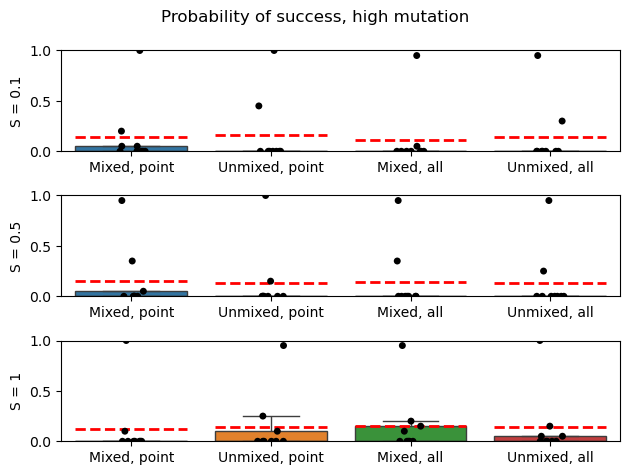

In [37]:
_, axs_high = conditions_boxplotter(stats_high["probability_of_success"],
                                    suptitle="Probability of success, high mutation",
                                    ylim=(0, 1)
                                   )

#### Plot individual patterns

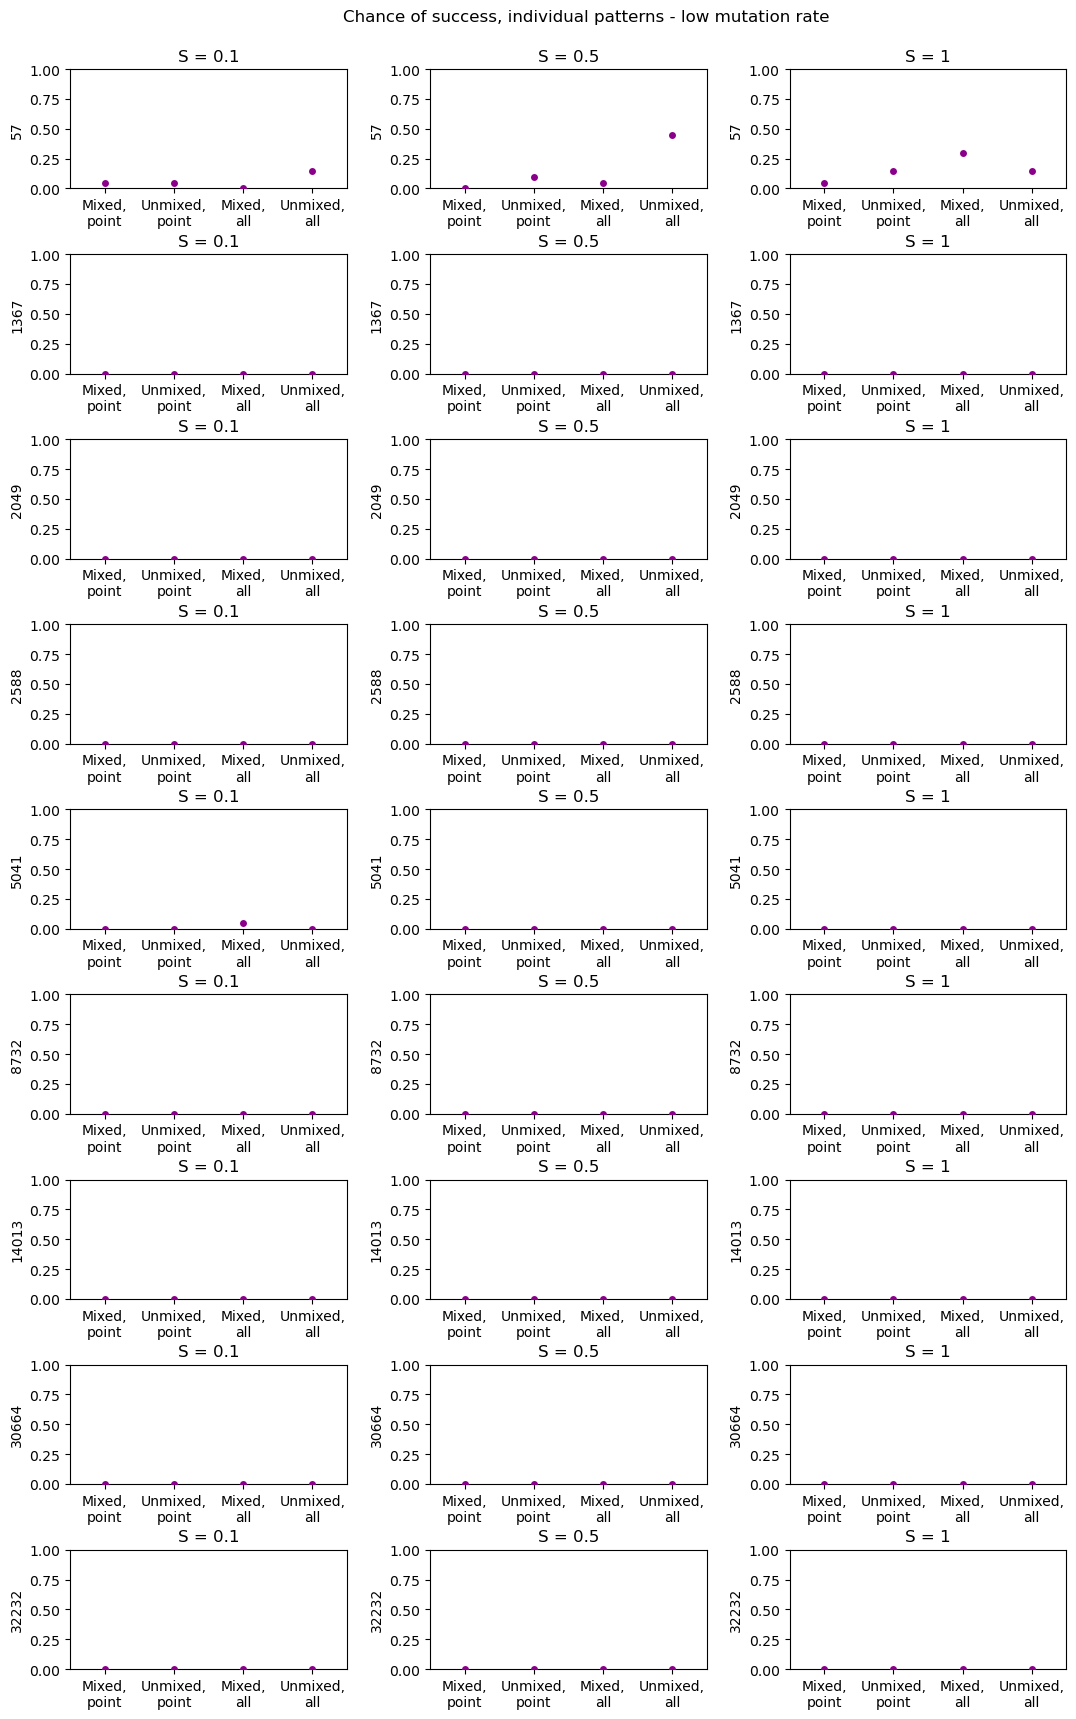

In [61]:
fig, axs = plt.subplots(len(patterns), len(sel_str_values), figsize=(12, 20))
#for ax, (d2, ss) in zip(axs, enumerate(sel_str_values)):
for row, p in enumerate(patterns):
    for col, ss in enumerate(sel_str_values):
        values = []
        labels = []
        for d1, mut in enumerate(["point", "all"]):
            for d3, mix in enumerate(["Mixed", "Unmixed"]):
                values.append(stats_low["probability_of_success"][row, d1, col, d3])
                labels.append(mix + ",\n" + mut)
        ax = axs[row][col]
        sns.stripplot(data=pd.DataFrame(dict(zip(labels, [np.array([v]) for v in values]))),
                      ax=ax,
                      palette=["darkmagenta" for i in range(4)]
                     )
        ax.set_ylim(0, 1)
        ax.set_title("S = " + str(ss))
        ax.set_ylabel(p, rotation=90)
    

    
plt.subplots_adjust(wspace=0.3, hspace=0.55, left=0.07, right=0.9, top=0.95, bottom=0.15)
plt.suptitle("Chance of success, individual patterns - low mutation rate")
plt.show()

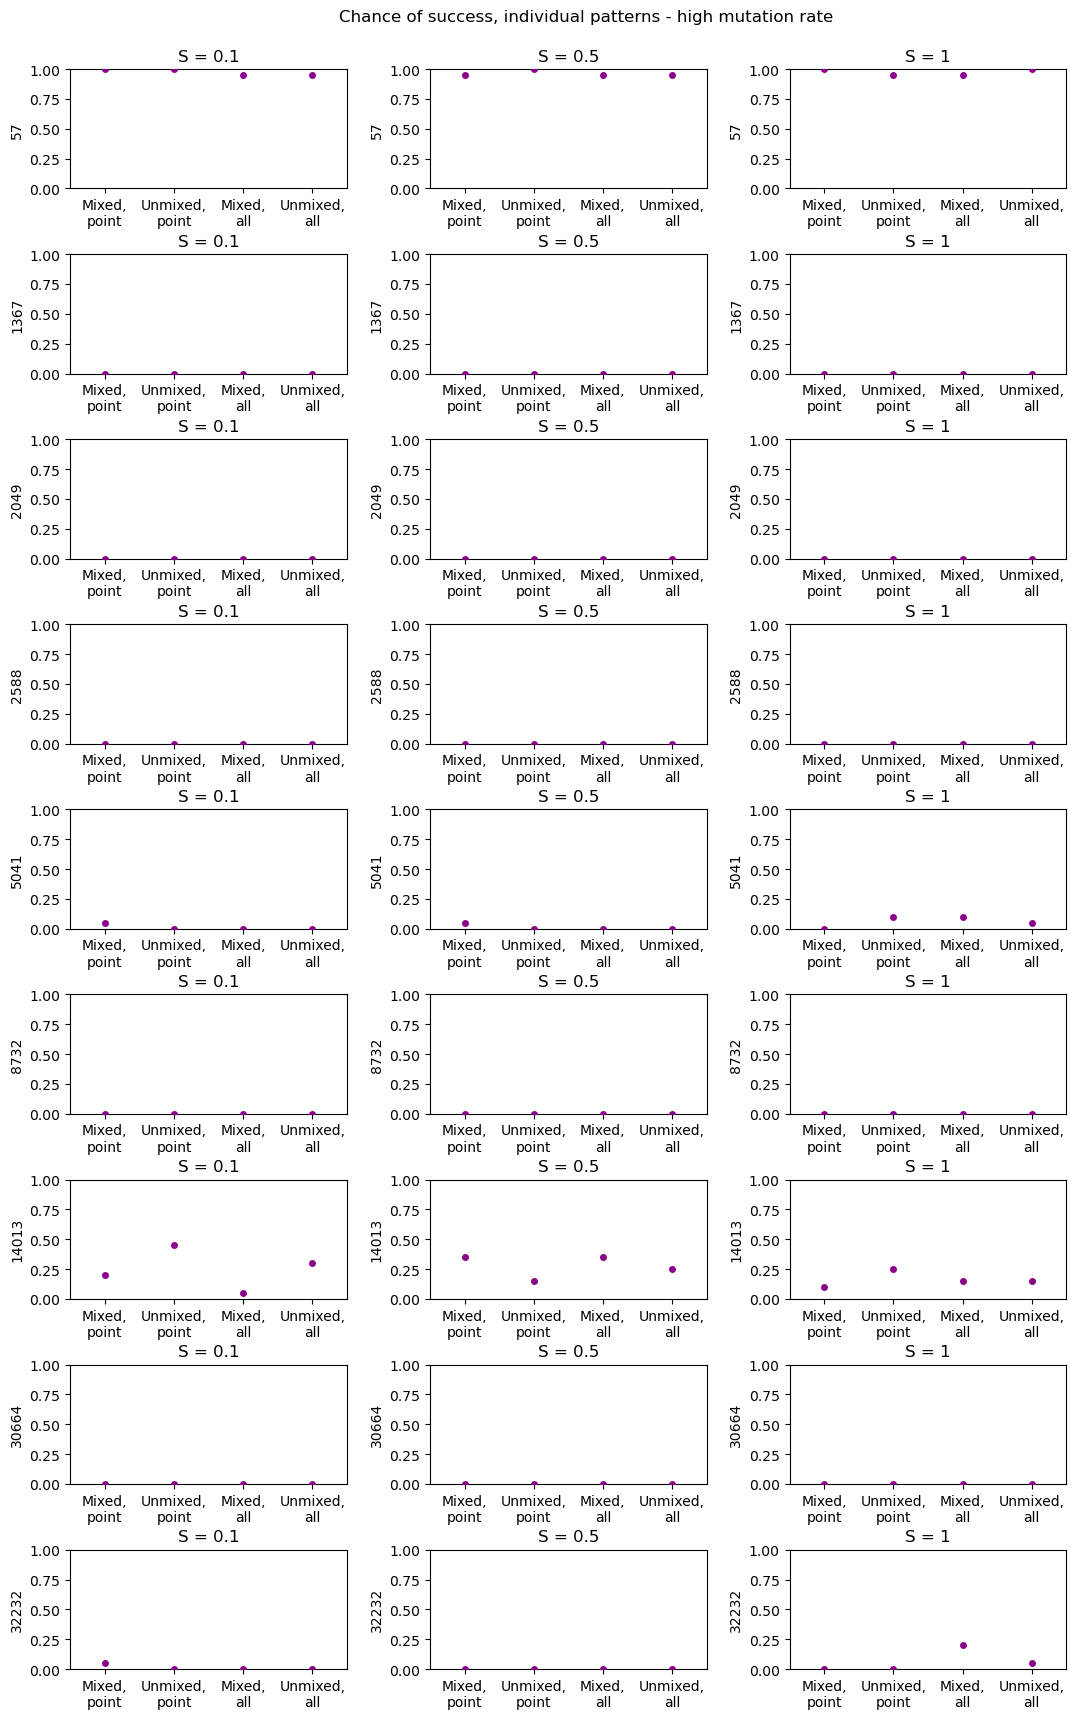

In [60]:
fig, axs = plt.subplots(len(patterns), len(sel_str_values), figsize=(12, 20))
#for ax, (d2, ss) in zip(axs, enumerate(sel_str_values)):
for row, p in enumerate(patterns):
    for col, ss in enumerate(sel_str_values):
        values = []
        labels = []
        for d1, mut in enumerate(["point", "all"]):
            for d3, mix in enumerate(["Mixed", "Unmixed"]):
                values.append(stats_high["probability_of_success"][row, d1, col, d3])
                labels.append(mix + ",\n" + mut)
        ax = axs[row][col]
        sns.stripplot(data=pd.DataFrame(dict(zip(labels, [np.array([v]) for v in values]))),
                      ax=ax,
                      palette=["darkmagenta" for i in range(4)]
                     )
        ax.set_ylim(0, 1)
        ax.set_title("S = " + str(ss))
        ax.set_ylabel(p, rotation=90)
 
    
plt.subplots_adjust(wspace=0.3, hspace=0.55, left=0.07, right=0.9, top=0.95, bottom=0.15)
plt.suptitle("Chance of success, individual patterns - high mutation rate")
plt.show()